# 2026 Formula 1 — Exploratory Data Analysis

Ahead of modelling the **Dutch Grand Prix (round 12, Zandvoort)**.

All data logic lives in `src/`; this notebook only reads, summarises and draws.
Every chart is drawn from the data in the cell above it — **no figure is stored
as an image file**, so the plots cannot drift out of step with the numbers.
Features come from `src.features.load_model_table()`, raw session data from
`src.io_utils.load_raw()`, and every colour from `fastf1.plotting`'s official
2026 constants via `src.viz`.

**No model is fitted here.** The purpose is to decide what to model, what the
baseline is, and which features are worth carrying forward.

In [1]:
import sys
import warnings
from pathlib import Path

# Resolve the project root whether this runs from notebooks/ or the repo root.
BASE = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
sys.path.insert(0, str(BASE))


warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D

from src import viz
from src.features import FEATURE_COLUMNS, load_model_table, load_raw_frames

viz.apply_style()
pd.set_option("display.width", 180)
pd.set_option("display.max_columns", 60)

table = load_model_table()
raw = load_raw_frames()
results, laps, weather, schedule = raw["results"], raw["laps"], raw["weather"], raw["schedule"]

# Nullable booleans are the right dtype for the table as a whole - targets are
# genuinely NA on the round 12 prediction rows - but they propagate Float64
# through every aggregation, which matplotlib cannot plot. Pin the flags to
# plain bool here, where the gaps are already accounted for.
BOOL_COLS = ([c for c in table.columns if c.endswith("_imputed")]
             + ["won", "podium", "dnf", "dnf_first_lap", "dnf_after_lap1",
                "dns", "is_trainable", "is_prediction", "is_sprint",
                "is_sprint_weekend", "has_sprint_data", "was_wet"])
for col in [c for c in dict.fromkeys(BOOL_COLS) if c in table.columns]:
    table[col] = table[col].fillna(False).astype(bool)

# Rows with a real, scoreable outcome: excludes DNS and the unraced round 12.
train = table[table["is_trainable"]].copy()
predict = table[table["is_prediction"]].copy()

print(f"model table   {table.shape[0]:>4} rows x {table.shape[1]} columns")
print(f"scoreable     {len(train):>4} rows")
print(f"to predict    {len(predict):>4} rows (round 12 race)")

model table    374 rows x 54 columns
scoreable      343 rows
to predict      22 rows (round 12 race)


---
## 1. Dataset overview

In [2]:
print("GRAIN: one row per (round, session_type, driver_id)")
print("  unique:", not table.duplicated(["round", "session_type", "driver_id"]).any())
print(f"  rounds: {table['round'].min()}-{table['round'].max()}   "
      f"drivers: {table['driver_id'].nunique()}   teams: {table['team_id'].nunique()}")

grain = (table.groupby(["session_type", "is_prediction"]).size()
         .rename("rows").reset_index())
grain["kind"] = np.where(grain["is_prediction"], "prediction", "labelled")
print()
print(grain[["session_type", "kind", "rows"]].to_string(index=False))

GRAIN: one row per (round, session_type, driver_id)
  unique: True
  rounds: 1-12   drivers: 23   teams: 11

session_type       kind  rows
           R   labelled   242
           R prediction    22
           S   labelled   110


In [3]:
# Sessions actually recorded per round, straight from the raw results.
per_round = (results.groupby(["round", "event_name"])["session_type"]
             .apply(lambda s: " ".join(sorted(set(s), key="FP1 FP2 FP3 SQ S Q R".split().index)))
             .rename("sessions with results"))
fmt = schedule.set_index("round")["EventFormat"]
overview = pd.concat([fmt.rename("format"), per_round.reset_index(level=1)], axis=1)
overview.index.name = "round"
print(overview.to_string())

                  format             event_name sessions with results
round                                                                
1           conventional  Australian Grand Prix                   Q R
2      sprint_qualifying     Chinese Grand Prix              SQ S Q R
3           conventional    Japanese Grand Prix                   Q R
4      sprint_qualifying       Miami Grand Prix              SQ S Q R
5      sprint_qualifying    Canadian Grand Prix              SQ S Q R
6           conventional      Monaco Grand Prix                   Q R
7           conventional   Barcelona Grand Prix                   Q R
8           conventional    Austrian Grand Prix                   Q R
9      sprint_qualifying     British Grand Prix              SQ S Q R
10          conventional     Belgian Grand Prix                   Q R
11          conventional   Hungarian Grand Prix                   Q R
12     sprint_qualifying       Dutch Grand Prix                SQ S Q


In [4]:
roster = (table.groupby(["team_name", "abbreviation"])["driver_id"].first()
          .reset_index().groupby("team_name")
          .agg(drivers=("abbreviation", lambda s: ", ".join(sorted(set(s)))),
               n=("abbreviation", "nunique")))
print(f"{table['driver_id'].nunique()} drivers across {len(roster)} teams, "
      f"in {int(roster['n'].sum())} team-driver pairings\n")
print(roster.to_string())

moved = table.groupby("abbreviation")["team_name"].nunique()
moved = moved[moved > 1]
if len(moved):
    print("\nSURPRISE - drivers who changed team mid-season:")
    for abbr in moved.index:
        spell = (table[table["abbreviation"] == abbr]
                 .groupby("team_name")["round"].agg(["min", "max"]))
        for team, row in spell.iterrows():
            print(f"  {abbr}: {team} (rounds {int(row['min'])}-{int(row['max'])})")

23 drivers across 11 teams, in 24 team-driver pairings

                       drivers  n
team_name                        
Alpine                COL, GAS  2
Aston Martin          ALO, STR  2
Audi                  BOR, HUL  2
Cadillac              BOT, PER  2
Ferrari               HAM, LEC  2
Haas F1 Team          BEA, OCO  2
McLaren               NOR, PIA  2
Mercedes              ANT, RUS  2
Racing Bulls     LAW, LIN, TSU  3
Red Bull Racing  HAD, LAW, VER  3
Williams              ALB, SAI  2

SURPRISE - drivers who changed team mid-season:
  LAW: Racing Bulls (rounds 1-11)
  LAW: Red Bull Racing (rounds 12-12)


**Flagged.** Three teams show more than two drivers because of driver movement,
not a rule change: there are **23 unique drivers filling 24 team-driver
pairings**, because Lawson moved from Racing Bulls to Red Bull Racing for round
12 — this weekend. Anything keyed on a season-level driver-to-team mapping would
mis-assign his Zandvoort rows, which is why `src.features` resolves `team_id`
per round rather than per season. Round 12's entry also includes Tsunoda, who
appears in no earlier round.

Note also that the "sessions with results" column shows only `Q R` / `SQ S Q R`:
practice sessions produce laps but no classified results, so they are absent by
design rather than missing.

### Missingness

The table is imputed by construction — `src.features` never drops a row for a
missing feature — so the honest missingness view is the **share of each feature
that had to be imputed**, read from the `*_imputed` flags.

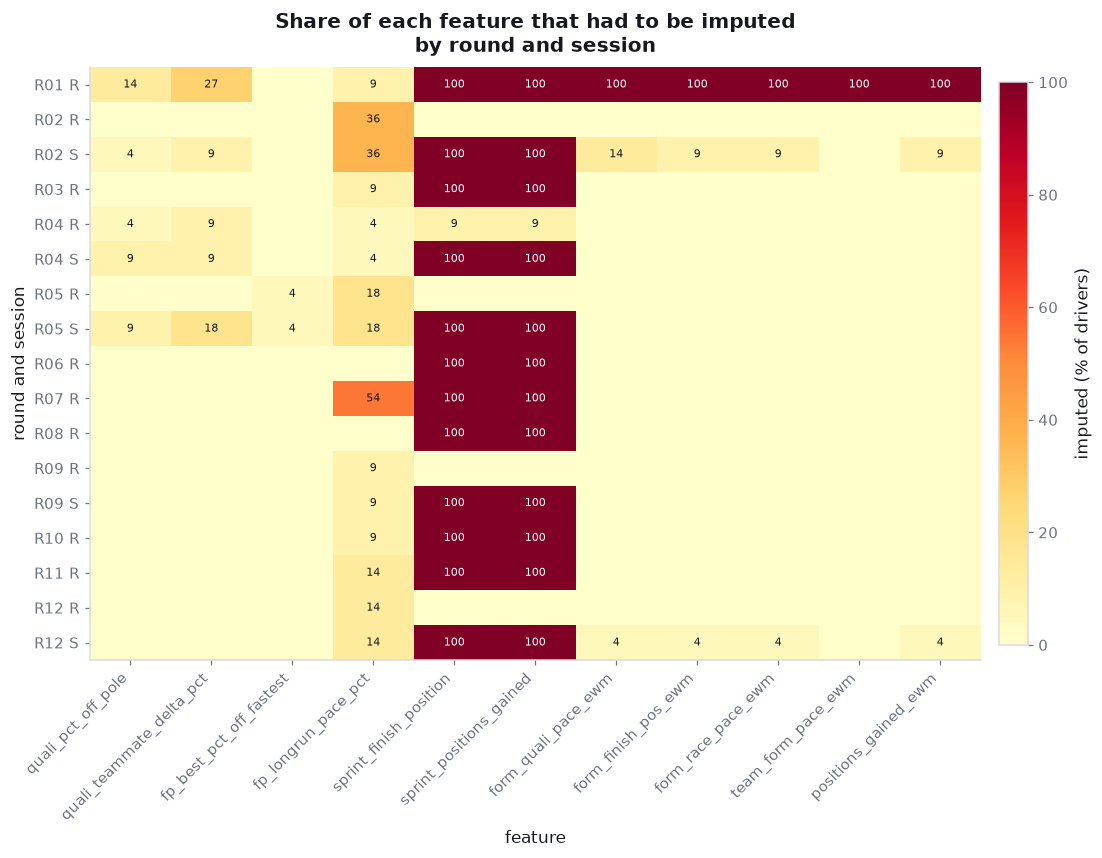

never imputed: ['grid_position', 'has_sprint_data', 'dnf_rate_shrunk', 'championship_position', 'track_temp_mean', 'was_wet']


In [5]:
flags = [f"{c}_imputed" for c in FEATURE_COLUMNS if f"{c}_imputed" in table.columns]
miss = (table.groupby(["round", "session_type"])[flags].mean()
        .astype("float64").mul(100).round(1))
miss.columns = [c.replace("_imputed", "") for c in miss.columns]
miss = miss.loc[:, miss.max() > 0]  # drop features that were never imputed

fig, ax = plt.subplots(figsize=(11, 7))
im = ax.imshow(miss.to_numpy(), aspect="auto", cmap="YlOrRd",
               vmin=0, vmax=100)
ax.set_xticks(range(len(miss.columns)))
ax.set_xticklabels(miss.columns, rotation=45, ha="right")
ax.set_yticks(range(len(miss)))
ax.set_yticklabels([f"R{r:02d} {s}" for r, s in miss.index])
for i in range(miss.shape[0]):
    for j in range(miss.shape[1]):
        v = miss.iat[i, j]
        if v > 0:
            ax.text(j, i, f"{v:.0f}", ha="center", va="center", fontsize=7.5,
                    color="white" if v > 55 else viz.INK)
ax.set_title("Share of each feature that had to be imputed\nby round and session")
ax.set_xlabel("feature")
ax.set_ylabel("round and session")
ax.grid(False)
fig.colorbar(im, ax=ax, label="imputed (% of drivers)", fraction=0.03, pad=0.02)
plt.show()

never = [c for c in FEATURE_COLUMNS if f"{c}_imputed" in table.columns
         and not table[f"{c}_imputed"].any()]
print("never imputed:", never)

**What it shows.** Imputation share per feature per session. Three things stand out
and all three are structural rather than accidental:

1. **Round 1 form is 100% imputed.** Nobody has a prior race in a season that
   starts at round 1, so every rolling feature falls back to a same-session
   proxy. Round 1 carries the least information of any race in the set and
   should be expected to be the worst-predicted.
2. **`sprint_finish_position` is 100% imputed on every Sprint row and every
   non-sprint round.** By design: a Sprint row cannot use its own result, and
   there is no sprint to read at a conventional weekend. The `has_sprint_data`
   flag marks the difference, and the rows are kept because dropping them would
   cost two thirds of the training data.
3. **Round 7 (Barcelona) is 54% imputed on `fp_longrun_pace_pct`.** This one is
   a genuine data-quality dent: FastF1's accuracy check rejects 54% of that
   weekend's practice laps against roughly 39% elsewhere, leaving only 10
   drivers with a clean long run. Treat round 7 practice pace as weak evidence.

---
## 2. The 2026 regulation reset

This is the project's headline constraint, so it goes early.

> ### Why this project trains on 11 races and not 10 seasons
>
> **2026 is a complete technical reset.** New chassis and aerodynamic regulations
> (active aero, a substantially different downforce and drag profile) arrived
> alongside a new power unit formula (roughly 50/50 internal combustion and
> electrical, 100% sustainable fuel). The competitive order was rebuilt from
> scratch — the grid gained Audi and Cadillac, and the 2025 pecking order does
> not survive into 2026.
>
> **Therefore no pre-2026 data is usable for pace.** A lap time, a qualifying
> gap or a team's race pace from 2025 describes a car that no longer exists
> under rules that no longer apply. Pooling it in would not add signal; it would
> add confidently-wrong signal, and a backtest would not reveal that because
> the leakage is conceptual rather than temporal.
>
> **The cost is sample size.** Eleven races and five sprints, 343 scoreable
> driver-sessions. That is a small-data problem, and it dictates the modelling
> posture downstream: strong priors, heavy shrinkage, few parameters, and deep
> suspicion of any feature that looks powerful on this much data.

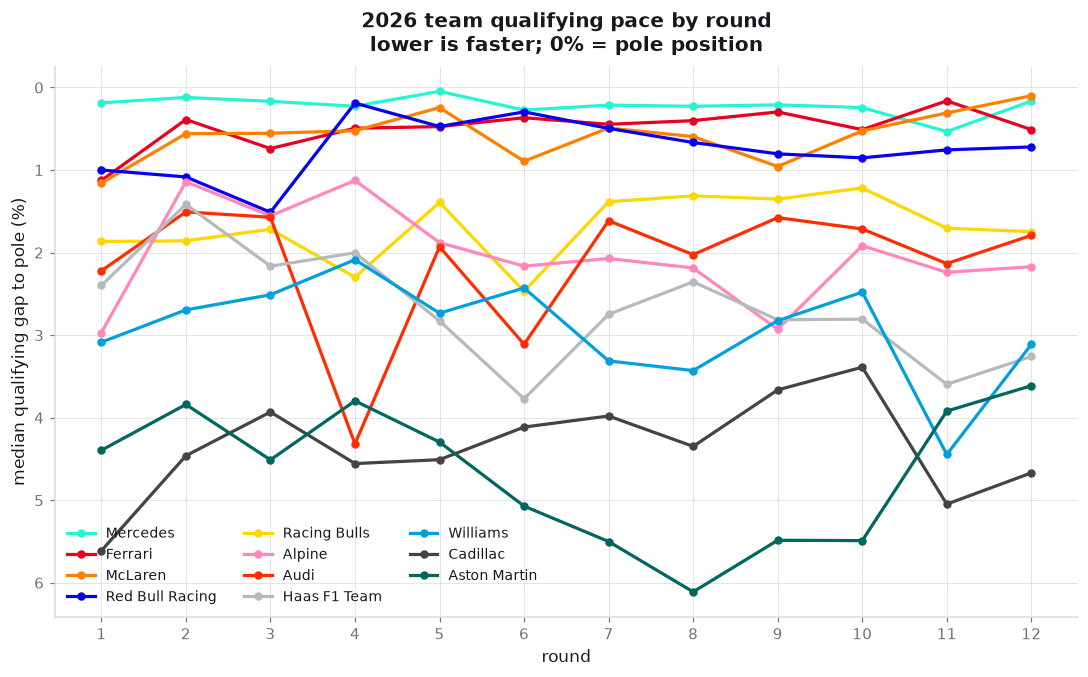

                 season median gap to pole (%)
team_name                                     
Mercedes                                  0.22
Ferrari                                   0.49
McLaren                                   0.58
Red Bull Racing                           0.74
Racing Bulls                              1.69
Alpine                                    2.03
Audi                                      2.13
Haas F1 Team                              2.68
Williams                                  2.93
Cadillac                                  4.36
Aston Martin                              4.67


In [6]:
# Team qualifying pace by round. Measured values only - imputed quali pace would
# draw a line through a number nobody set.
qp = table[(table["session_type"] == "R") & (~table["quali_pct_off_pole_imputed"])]
pace = qp.groupby(["round", "team_name"])["quali_pct_off_pole"].median().unstack()
order = pace.mean().sort_values().index

fig, ax = plt.subplots(figsize=(12, 6.5))
for team in order:
    ax.plot(pace.index, pace[team], marker="o", markersize=4.5,
            color=viz.team_color(team), label=team, linewidth=2.1)
ax.set_xlabel("round")
ax.set_ylabel("median qualifying gap to pole (%)")
ax.set_title("2026 team qualifying pace by round\nlower is faster; 0% = pole position")
ax.set_xticks(pace.index)
ax.invert_yaxis()
ax.legend(ncol=3, loc="lower left", fontsize=9)
plt.show()

season = pace.mean().sort_values().round(2).rename("season median gap to pole (%)")
print(season.to_frame().to_string())

**What it shows.** Each team's median qualifying deficit to pole, round by round,
in official 2026 colours. The y-axis is inverted so higher on the chart means
faster. This is the competitive order of the new regulations and how it has
moved: the spread between the front and the back of the grid, and whether any
team's line is trending across the season rather than sitting flat. It matters
because a team on a trajectory is mispriced by any feature that averages its
season, which is exactly what the EWM form features are built to handle.

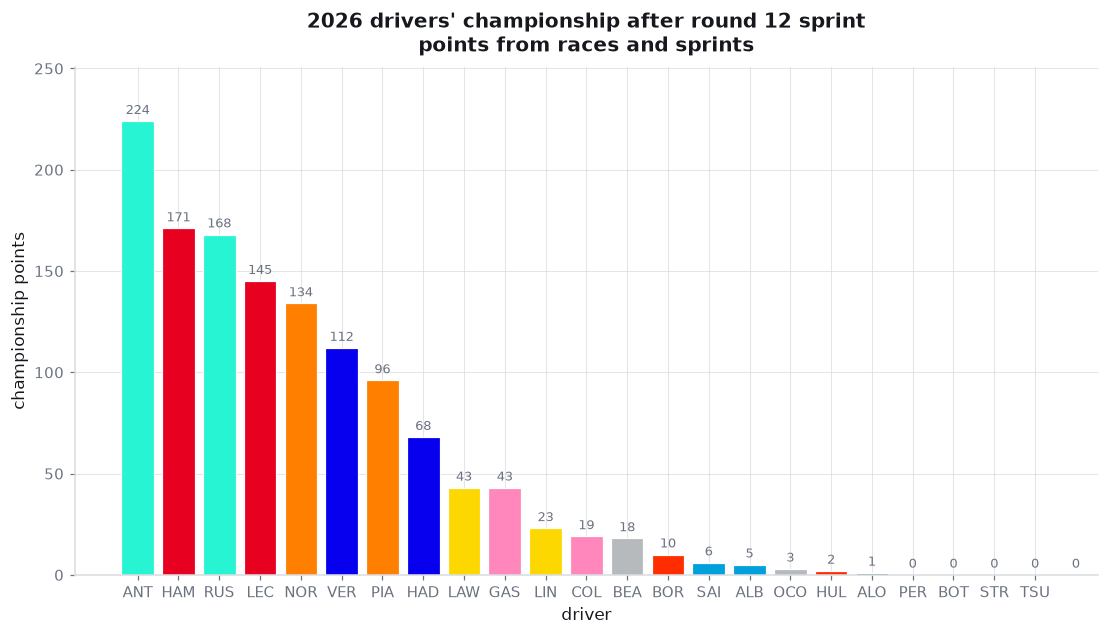

constructors:
TeamName
Mercedes           392.0
Ferrari            316.0
McLaren            230.0
Red Bull Racing    180.0
Racing Bulls        66.0
Alpine              62.0
Haas F1 Team        21.0
Audi                12.0
Williams            11.0
Aston Martin         1.0
Cadillac             0.0


In [7]:
# Championship points come from the raw results: races and sprints both score.
scoring = results[results["session_type"].isin(["R", "S"])]
standings = (scoring.groupby(["DriverId", "Abbreviation", "TeamName"])["Points"].sum()
             .reset_index().sort_values("Points", ascending=False))

fig, ax = plt.subplots(figsize=(12, 6))
ax.bar(standings["Abbreviation"], standings["Points"],
       color=viz.team_colors(standings["TeamName"]), edgecolor="white", linewidth=0.8)
for x, (pts, abbr) in enumerate(zip(standings["Points"], standings["Abbreviation"])):
    ax.text(x, pts + 2, f"{pts:.0f}", ha="center", va="bottom", fontsize=8.5, color=viz.MUTED)
ax.set_xlabel("driver")
ax.set_ylabel("championship points")
ax.set_title("2026 drivers' championship after round 12 sprint\npoints from races and sprints")
ax.set_ylim(0, standings["Points"].max() * 1.12)
plt.show()

teams = (scoring.groupby("TeamName")["Points"].sum().sort_values(ascending=False))
print("constructors:")
print(teams.round(0).to_string())

**What it shows.** Current drivers' standings in team colours, with the
constructors' totals underneath. This is the target's context: the spread
between teammates on the same bar colour is the part a model can attribute to
the driver, and everything else is the car. It matters because
`championship_position` enters the feature set, and a chart like this makes
clear it is largely a restatement of team strength rather than independent
information.

---
## 3. What actually predicts finishing position

Establishing the baseline before any model exists. If a model cannot beat what
follows, it is not worth deploying.

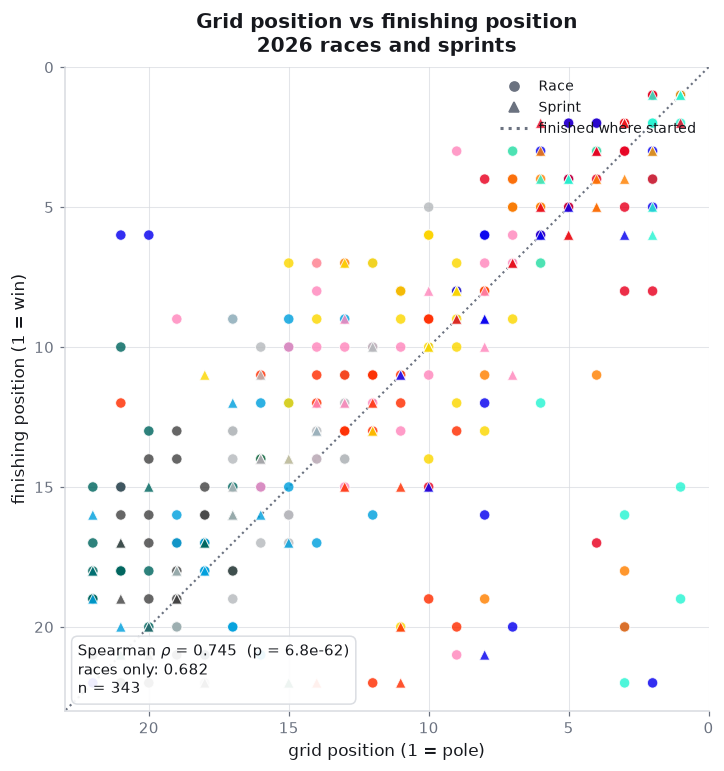

In [8]:
from scipy.stats import spearmanr

races = train[train["session_type"] == "R"]
sprints = train[train["session_type"] == "S"]

rho_all, p_all = spearmanr(train["grid_position"], train["finish_position"])
rho_race, _ = spearmanr(races["grid_position"], races["finish_position"])

fig, ax = plt.subplots(figsize=(8.2, 7.6))
ax.plot([0, 23], [0, 23], color=viz.MUTED, linestyle=":", linewidth=1.4, zorder=1,
        label="finished where started")
for subset, marker, label in [(races, "o", "Race"), (sprints, "^", "Sprint")]:
    ax.scatter(subset["grid_position"], subset["finish_position"],
               c=viz.team_colors(subset["team_name"]), marker=marker, s=46,
               alpha=0.82, edgecolor="white", linewidth=0.6, zorder=3, label=label)
ax.set_xlabel("grid position (1 = pole)")
ax.set_ylabel("finishing position (1 = win)")
ax.set_title("Grid position vs finishing position\n2026 races and sprints")
ax.set_xlim(0, 23); ax.set_ylim(0, 23)
ax.invert_yaxis(); ax.invert_xaxis()
ax.set_aspect("equal")
viz.annotate(ax, f"Spearman $\\rho$ = {rho_all:.3f}  (p = {p_all:.1e})\n"
                 f"races only: {rho_race:.3f}\nn = {len(train)}", loc="lower left")
handles = [Line2D([], [], marker=m, linestyle="none", color=viz.MUTED, label=l)
           for m, l in [("o", "Race"), ("^", "Sprint")]]
handles.append(Line2D([], [], linestyle=":", color=viz.MUTED, label="finished where started"))
ax.legend(handles=handles, loc="upper right")
plt.show()

**What it shows.** Where each driver started against where they finished, points
in team colours, with the diagonal marking "held station". The Spearman rank
correlation is the number to beat. It matters because this single variable, with
no model at all, already explains most of the finishing order — which sets a
brutally high floor for anything more complicated.

In [9]:
# Baseline B1: the empirical grid-position lookup table.
buckets = [(1, 1, "P1"), (2, 3, "P2-3"), (4, 6, "P4-6"),
           (7, 10, "P7-10"), (11, 15, "P11-15"), (16, 22, "P16-22")]
rows = []
for lo, hi, label in buckets:
    sel = train[train["grid_position"].between(lo, hi)]
    if sel.empty:
        continue
    rows.append({
        "grid bucket": label,
        "n": len(sel),
        "P(win)": float(sel["won"].mean()),
        "P(podium)": float(sel["podium"].mean()),
        "P(DNF)": float(sel["dnf"].mean()),
        "median finish": sel["finish_position"].median(),
        "mean pos gained": sel["positions_gained"].mean(),
    })
b1 = pd.DataFrame(rows)
print("BASELINE B1 - empirical outcome by grid bucket (2026 races + sprints)")
print(b1.to_string(index=False, float_format=lambda v: f"{v:.3f}"))
print(f"\nAny model must beat this. Naive 'finish where you started' MAE = "
      f"{(train['finish_position'] - train['grid_position']).abs().mean():.2f} positions.")

BASELINE B1 - empirical outcome by grid bucket (2026 races + sprints)
grid bucket   n  P(win)  P(podium)  P(DNF)  median finish  mean pos gained
         P1  16   0.750      0.875   0.062          1.000           -2.125
       P2-3  32   0.125      0.500   0.188          3.500           -3.938
       P4-6  45   0.000      0.333   0.022          4.000            0.244
      P7-10  63   0.000      0.048   0.111          8.000           -0.921
     P11-15  78   0.000      0.000   0.115         12.000            0.577
     P16-22 109   0.000      0.000   0.257         17.000            2.220

Any model must beat this. Naive 'finish where you started' MAE = 2.89 positions.


**What it shows.** Baseline **B1**: the empirical probability of a win, a podium
and a DNF for each starting-position band, with sample counts so the reliability
of each row is visible. It matters because it is the honest benchmark — a lookup
table with one input — and because the counts show how thin the top rows are:
every P1 estimate rests on a handful of sessions.

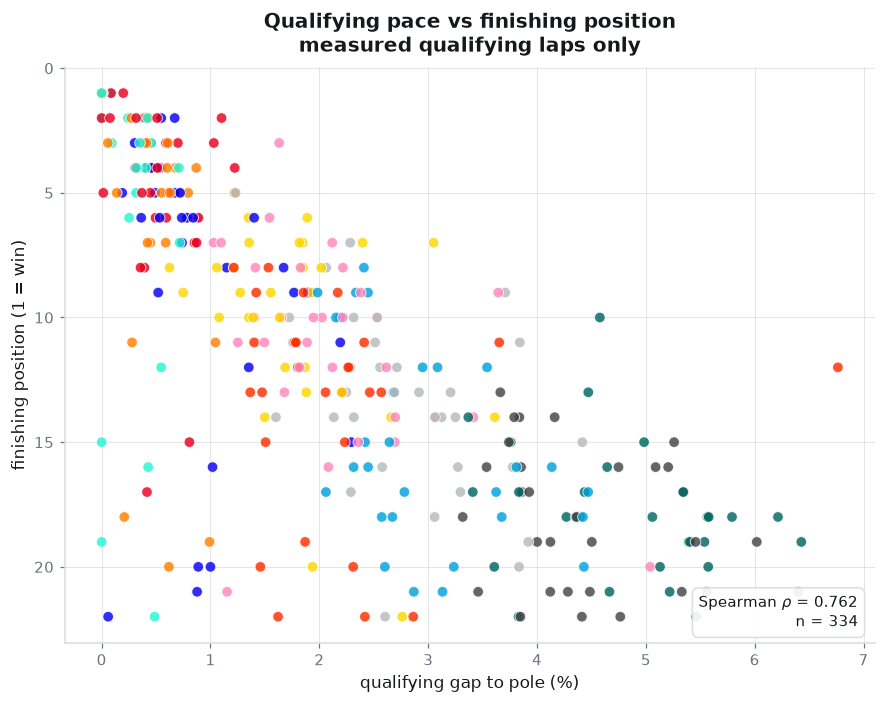

grid_position       rho = 0.745
quali_pct_off_pole  rho = 0.762  (measured laps only)


In [10]:
rho_q, _ = spearmanr(train["quali_pct_off_pole"], train["finish_position"])
measured = train[~train["quali_pct_off_pole_imputed"]]
rho_qm, _ = spearmanr(measured["quali_pct_off_pole"], measured["finish_position"])

fig, ax = plt.subplots(figsize=(9.5, 6.8))
ax.scatter(measured["quali_pct_off_pole"], measured["finish_position"],
           c=viz.team_colors(measured["team_name"]), s=48, alpha=0.82,
           edgecolor="white", linewidth=0.6)
ax.set_xlabel("qualifying gap to pole (%)")
ax.set_ylabel("finishing position (1 = win)")
ax.set_title("Qualifying pace vs finishing position\nmeasured qualifying laps only")
ax.invert_yaxis()
viz.annotate(ax, f"Spearman $\\rho$ = {rho_qm:.3f}\nn = {len(measured)}", loc="lower right")
plt.show()

print(f"grid_position       rho = {rho_all:.3f}")
print(f"quali_pct_off_pole  rho = {rho_qm:.3f}  (measured laps only)")

**What it shows.** Raw qualifying pace, as a percentage deficit to pole, against
race outcome. Unlike grid position this is a continuous measure of car and driver
speed and is not distorted by grid penalties. It matters because it separates
*being fast* from *starting near the front*: the two are close to interchangeable
predictors, which becomes a collinearity problem in section 5.

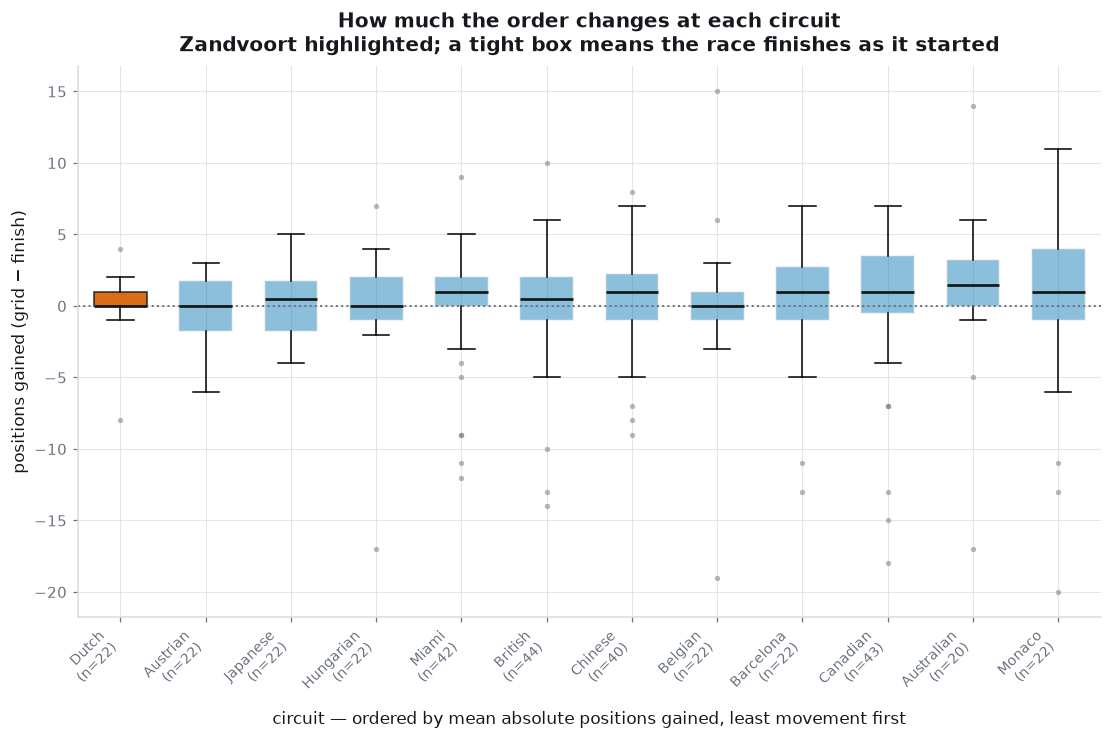

             iqr   mad   n
circuit                   
Dutch       1.00  1.09  22
Austrian    3.50  1.82  22
Japanese    3.50  2.00  22
Hungarian   3.00  2.45  22
Miami       2.00  2.79  42
British     3.00  2.86  44
Chinese     3.25  2.88  40
Belgian     2.00  2.91  22
Barcelona   3.75  3.09  22
Canadian    4.00  3.60  43
Australian  3.25  3.65  20
Monaco      5.00  5.09  22


In [11]:
# Overtaking by circuit: spread of positions gained, ordered by how little moves.
pg = train.dropna(subset=["positions_gained"]).copy()
pg["circuit"] = pg["event_name"].str.replace(" Grand Prix", "", regex=False)
stats = (pg.groupby("circuit")["positions_gained"]
         .agg(iqr=lambda s: s.quantile(0.75) - s.quantile(0.25),
              mad=lambda s: s.abs().mean(), n="size")
         .sort_values("mad"))
groups = [pg.loc[pg["circuit"] == c, "positions_gained"].to_numpy() for c in stats.index]

fig, ax = plt.subplots(figsize=(12, 6.5))
bp = ax.boxplot(groups, patch_artist=True, widths=0.62,
                medianprops={"color": viz.INK, "linewidth": 1.8},
                flierprops={"marker": "o", "markersize": 3.5, "alpha": 0.5,
                            "markerfacecolor": viz.MUTED, "markeredgecolor": "none"})
for patch, circuit in zip(bp["boxes"], stats.index):
    is_zandvoort = circuit == "Dutch"
    patch.set_facecolor(viz.WARN if is_zandvoort else viz.ACCENT)
    patch.set_alpha(0.9 if is_zandvoort else 0.45)
    patch.set_edgecolor(viz.INK if is_zandvoort else viz.GRID)
ax.axhline(0, color=viz.MUTED, linestyle=":", linewidth=1.3)
ax.set_xticks(range(1, len(groups) + 1))
ax.set_xticklabels([f"{c}\n(n={int(stats.loc[c, 'n'])})" for c in stats.index],
                   rotation=45, ha="right", fontsize=9)
ax.set_xlabel("circuit — ordered by mean absolute positions gained, least movement first")
ax.set_ylabel("positions gained (grid − finish)")
ax.set_title("How much the order changes at each circuit\nZandvoort highlighted; "
             "a tight box means the race finishes as it started")
plt.show()

print(stats.round(2).to_string())

**What it shows.** The distribution of positions gained at each circuit, ordered
so the hardest places to overtake come first, with Zandvoort highlighted.

**Zandvoort is at the wrong end of this chart, and that is the single most
important contextual fact for Sunday.** It sits lowest of all twelve circuits on
both interquartile range (1.00) and mean absolute movement (1.09) — a narrow,
steeply banked track with one genuine passing opportunity and a pit lane that
constrains strategy. The order finishes close to how it started.

**Caveat, and it matters for reading the rest of the chart: this measures
*movement*, not *overtaking*.** A retirement moves everyone behind it up a
place, so attrition inflates the same statistic. Across circuits, mean absolute
positions gained correlates with the DNF rate at r = 0.63, and Monaco — the
hardest circuit on the calendar to pass at — tops the chart precisely because it
also had the highest DNF rate (31.8%). Recomputing on finishers only separates
the two effects cleanly: **Zandvoort 0.76 positions, Monaco 3.87**. The Zandvoort
conclusion survives; the Monaco reading was an artifact.

Practically: for the Dutch Grand Prix, `grid_position` should be weighted *more*
heavily than the season average implies, and a model predicting large position
changes at Zandvoort should be treated as wrong before it is treated as clever.
The sample here is the round 12 **sprint** only — the race has not been run.

---
## 4. Reliability

Finishing requires the car to last. With eleven races, raw retirement rates are
mostly noise, which is the argument for the shrunk estimator.

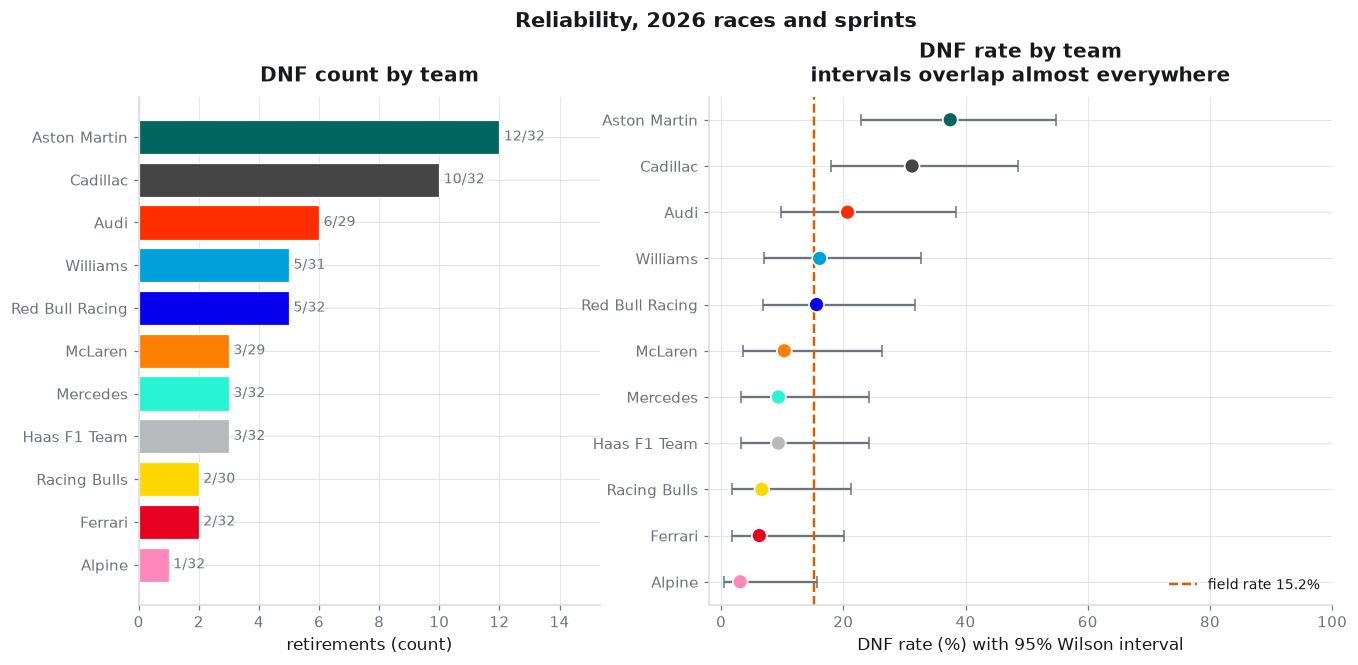

                 starts  dnfs  rate    lo    hi
team_name                                      
Alpine               32     1   3.1   0.6  15.7
Ferrari              32     2   6.2   1.7  20.1
Racing Bulls         30     2   6.7   1.8  21.3
Haas F1 Team         32     3   9.4   3.2  24.2
Mercedes             32     3   9.4   3.2  24.2
McLaren              29     3  10.3   3.6  26.4
Red Bull Racing      32     5  15.6   6.9  31.8
Williams             31     5  16.1   7.1  32.6
Audi                 29     6  20.7   9.8  38.4
Cadillac             32    10  31.2  18.0  48.6
Aston Martin         32    12  37.5  22.9  54.7


In [12]:
def wilson_interval(successes, n, z=1.96):
    """Wilson score interval - behaves sensibly at small n and at 0%, unlike
    the normal approximation, which is why it is used here."""
    if n == 0:
        return np.nan, np.nan
    p = successes / n
    denom = 1 + z**2 / n
    centre = (p + z**2 / (2 * n)) / denom
    half = z * np.sqrt(p * (1 - p) / n + z**2 / (4 * n**2)) / denom
    return centre - half, centre + half


rel = (train.groupby("team_name")
       .agg(starts=("dnf", "size"), dnfs=("dnf", "sum"))
       .assign(rate=lambda d: d["dnfs"] / d["starts"])
       .sort_values("rate"))
rel[["lo", "hi"]] = [wilson_interval(d, n) for d, n in zip(rel["dnfs"], rel["starts"])]
field_rate = float(train["dnf"].mean())

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 6), gridspec_kw={"width_ratios": [1, 1.35]})

ax1.barh(rel.index, rel["dnfs"], color=viz.team_colors(rel.index),
         edgecolor="white", linewidth=0.8)
for y, (d, n) in enumerate(zip(rel["dnfs"], rel["starts"])):
    ax1.text(d + 0.15, y, f"{d}/{n}", va="center", fontsize=9, color=viz.MUTED)
ax1.set_xlabel("retirements (count)")
ax1.set_title("DNF count by team")
ax1.set_xlim(0, rel["dnfs"].max() * 1.28)

ax2.errorbar(rel["rate"] * 100, rel.index,
             xerr=[(rel["rate"] - rel["lo"]) * 100, (rel["hi"] - rel["rate"]) * 100],
             fmt="none", ecolor=viz.MUTED, elinewidth=1.5, capsize=4, zorder=2)
ax2.scatter(rel["rate"] * 100, rel.index, s=95, zorder=3,
            c=viz.team_colors(rel.index), edgecolor="white", linewidth=1.1)
ax2.axvline(field_rate * 100, color=viz.WARN, linestyle="--", linewidth=1.6,
            label=f"field rate {field_rate*100:.1f}%")
ax2.set_xlabel("DNF rate (%) with 95% Wilson interval")
ax2.set_title("DNF rate by team\nintervals overlap almost everywhere")
ax2.legend(loc="lower right")
ax2.set_xlim(-2, 100)
fig.suptitle("Reliability, 2026 races and sprints", fontsize=14, fontweight="bold", y=1.01)
plt.show()

print(rel.assign(rate=lambda d: (d["rate"] * 100).round(1),
                 lo=lambda d: (d["lo"] * 100).round(1),
                 hi=lambda d: (d["hi"] * 100).round(1)).to_string())

**What it shows.** Retirement counts and rates by team, with 95% Wilson intervals
(Wilson rather than the normal approximation because it stays sensible at small
counts and at a 0% observed rate).

It matters because of *where* the intervals overlap. Across the seven teams
between Alpine (3.1%) and Williams (16.1%) the intervals overlap almost
completely — on roughly 30 starts each, those teams' reliability is not
statistically distinguishable from one another or from the field average. But
the two worst are genuinely separated: **Aston Martin (37.5%, CI 22.9-54.7) and
Cadillac (31.2%, CI 18.0-48.6) do not overlap Alpine's interval at all.** So
there is real reliability signal at the extremes and essentially none in the
midfield, which is exactly the situation a shrinkage estimator is designed for —
it lets the extremes move while holding the indistinguishable middle together.

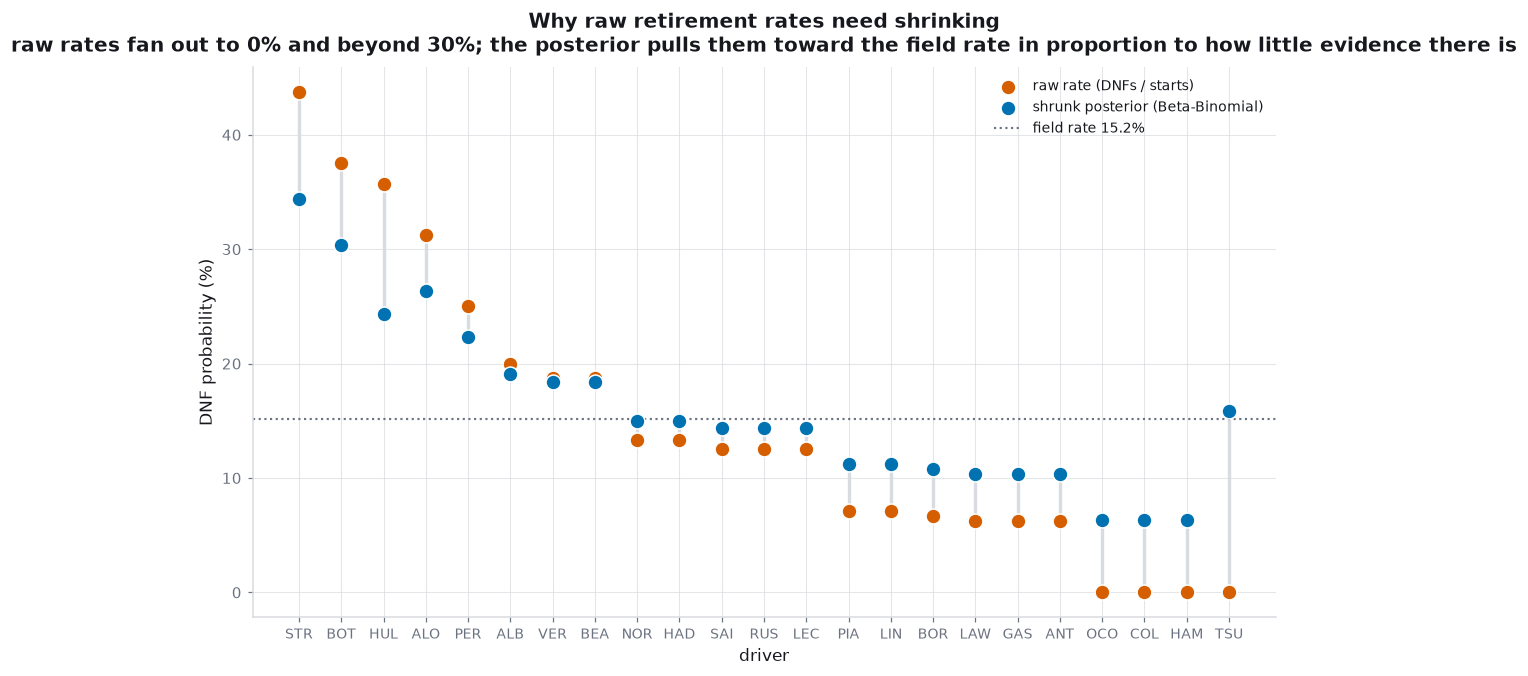

raw     spread: 0.0% - 43.8%  (sd 12.7)
shrunk  spread: 6.4% - 34.4%  (sd 7.5)


In [13]:
# The shrunk estimator, straight from src.features - dnf_rate_shrunk is the
# Beta-Binomial posterior each driver carried into their most recent session.
latest = (train.sort_values(["round", "session_type"])
          .groupby("driver_id").tail(1).set_index("driver_id"))
raw_rate = (train.groupby("driver_id")["dnf"]
            .agg(dnfs="sum", starts="size")
            .assign(raw=lambda d: d["dnfs"] / d["starts"]))
comp = raw_rate.join(latest[["abbreviation", "team_name", "dnf_rate_shrunk"]])
comp = comp.sort_values("raw", ascending=False)

fig, ax = plt.subplots(figsize=(12, 6.5))
x = np.arange(len(comp))
for xi, (_, row) in zip(x, comp.iterrows()):
    ax.plot([xi, xi], [row["raw"] * 100, row["dnf_rate_shrunk"] * 100],
            color=viz.GRID, linewidth=2.2, zorder=1, solid_capstyle="round")
ax.scatter(x, comp["raw"] * 100, s=95, color=viz.WARN, zorder=3,
           edgecolor="white", linewidth=1.0, label="raw rate (DNFs / starts)")
ax.scatter(x, comp["dnf_rate_shrunk"] * 100, s=95, color=viz.ACCENT, zorder=3,
           edgecolor="white", linewidth=1.0, label="shrunk posterior (Beta-Binomial)")
ax.axhline(field_rate * 100, color=viz.MUTED, linestyle=":", linewidth=1.4,
           label=f"field rate {field_rate*100:.1f}%")
ax.set_xticks(x)
ax.set_xticklabels(comp["abbreviation"], rotation=0, fontsize=9)
ax.set_xlabel("driver")
ax.set_ylabel("DNF probability (%)")
ax.set_title("Why raw retirement rates need shrinking\n"
             "raw rates fan out to 0% and beyond 30%; the posterior pulls them "
             "toward the field rate in proportion to how little evidence there is")
ax.legend(loc="upper right")
plt.show()

print(f"raw     spread: {comp['raw'].min()*100:.1f}% - {comp['raw'].max()*100:.1f}%  "
      f"(sd {comp['raw'].std()*100:.1f})")
print(f"shrunk  spread: {comp['dnf_rate_shrunk'].min()*100:.1f}% - "
      f"{comp['dnf_rate_shrunk'].max()*100:.1f}%  (sd {comp['dnf_rate_shrunk'].std()*100:.1f})")

**What it shows.** Each driver's raw retirement rate against the Beta-Binomial
posterior actually used as a feature, joined by a line so the size of the
correction is visible. It matters because the raw rates span 0% to well over 30%
on roughly a dozen starts each — a driver with 2 retirements in 11 is not twice
as fragile as one with 1, that difference is a coin flip. The posterior collapses
that spread toward the field rate and only lets a driver move away from it when
the count genuinely justifies it.

---
## 5. Feature diagnostics

Done before modelling, not after, because the answers change what gets built.

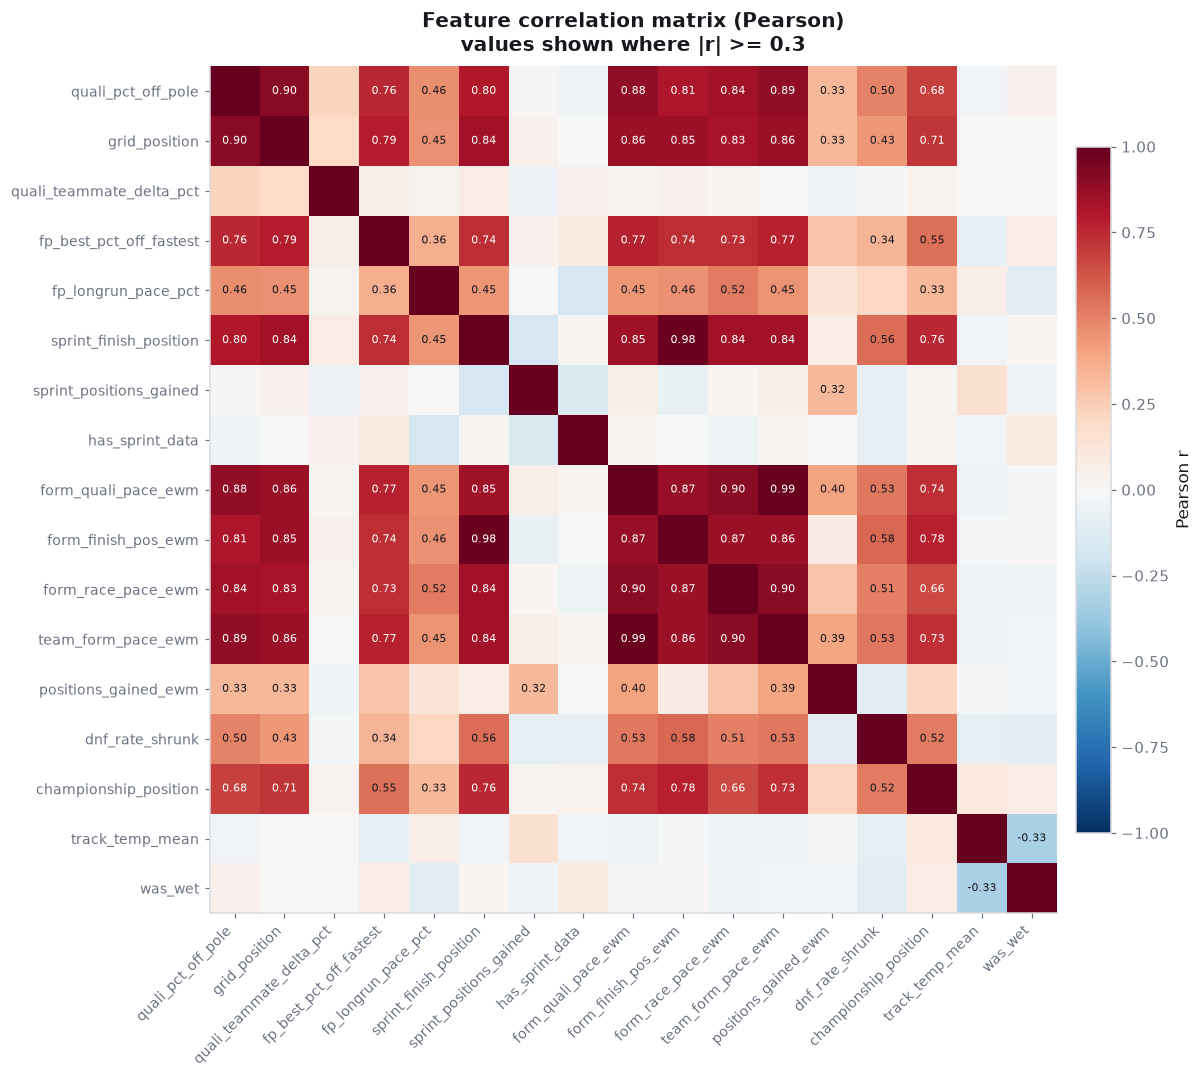

collinear pairs, |r| >= 0.70  (33 of 136):
              feature A               feature B     r
    form_quali_pace_ewm      team_form_pace_ewm 0.986
 sprint_finish_position     form_finish_pos_ewm 0.978
     form_race_pace_ewm      team_form_pace_ewm 0.904
     quali_pct_off_pole           grid_position 0.904
    form_quali_pace_ewm      form_race_pace_ewm 0.903
     quali_pct_off_pole      team_form_pace_ewm 0.889
     quali_pct_off_pole     form_quali_pace_ewm 0.884
    form_quali_pace_ewm     form_finish_pos_ewm 0.869
    form_finish_pos_ewm      form_race_pace_ewm 0.867
    form_finish_pos_ewm      team_form_pace_ewm 0.863
          grid_position      team_form_pace_ewm 0.863
          grid_position     form_quali_pace_ewm 0.862
          grid_position     form_finish_pos_ewm 0.854
 sprint_finish_position     form_quali_pace_ewm 0.847
 sprint_finish_position      form_race_pace_ewm 0.844
          grid_position  sprint_finish_position 0.841
 sprint_finish_position      team_form_

In [14]:
feat = train[FEATURE_COLUMNS].astype(float)
corr = feat.corr(method="pearson")

fig, ax = plt.subplots(figsize=(11.5, 10))
im = ax.imshow(corr.to_numpy(), cmap="RdBu_r", vmin=-1, vmax=1)
ax.set_xticks(range(len(corr))); ax.set_xticklabels(corr.columns, rotation=45, ha="right", fontsize=9)
ax.set_yticks(range(len(corr))); ax.set_yticklabels(corr.columns, fontsize=9)
for i in range(len(corr)):
    for j in range(len(corr)):
        v = corr.iat[i, j]
        if i != j and abs(v) >= 0.3:
            ax.text(j, i, f"{v:.2f}", ha="center", va="center", fontsize=7,
                    color="white" if abs(v) > 0.65 else viz.INK)
ax.set_title("Feature correlation matrix (Pearson)\nvalues shown where |r| >= 0.3")
ax.grid(False)
fig.colorbar(im, ax=ax, label="Pearson r", fraction=0.035, pad=0.02)
plt.show()

pairs = (corr.where(np.triu(np.ones(corr.shape), k=1).astype(bool)).stack()
         .rename("r").reset_index())
pairs.columns = ["feature A", "feature B", "r"]
strong = pairs[pairs["r"].abs() >= 0.70].sort_values("r", key=abs, ascending=False)
print(f"collinear pairs, |r| >= 0.70  ({len(strong)} of {len(pairs)}):")
print(strong.to_string(index=False, float_format=lambda v: f"{v:.3f}"))

**What it shows.** Pairwise correlation across all 17 features, with the strongly
collinear pairs listed underneath.

**`grid_position` and `quali_pct_off_pole` are close to redundant, and that
matters.** They measure the same thing by construction — the grid *is* the
qualifying order, save for penalties — so a linear model will split their
coefficient arbitrarily between them and neither will be individually
interpretable, while a tree model will dilute both by splitting on whichever it
happens to reach first. The family of `form_*` and `team_form_*` features is
similarly entangled, because both are driven by the car.

The scale of it is worse than one pair: **33 of 136 feature pairs sit at
|r| >= 0.70**, and `form_quali_pace_ewm` with `team_form_pace_ewm` reaches
r = 0.986. Downstream this argues for regularisation that handles correlated
inputs (ridge or elastic net rather than lasso), or for dropping one of each pair
and keeping the more directly measured one.

**One of these correlations is manufactured and should not be believed.**
`sprint_finish_position` correlates with `form_finish_pos_ewm` at r = 0.978 — but
`sprint_finish_position` is *imputed from* `form_finish_pos_ewm` on the 76% of
rows that have no sprint to read. The correlation is an artifact of the
imputation rule, not a property of the sport. Read it as a warning: any feature
that is mostly imputed will correlate with whatever imputed it, and its apparent
importance in a fitted model will be borrowed rather than earned.

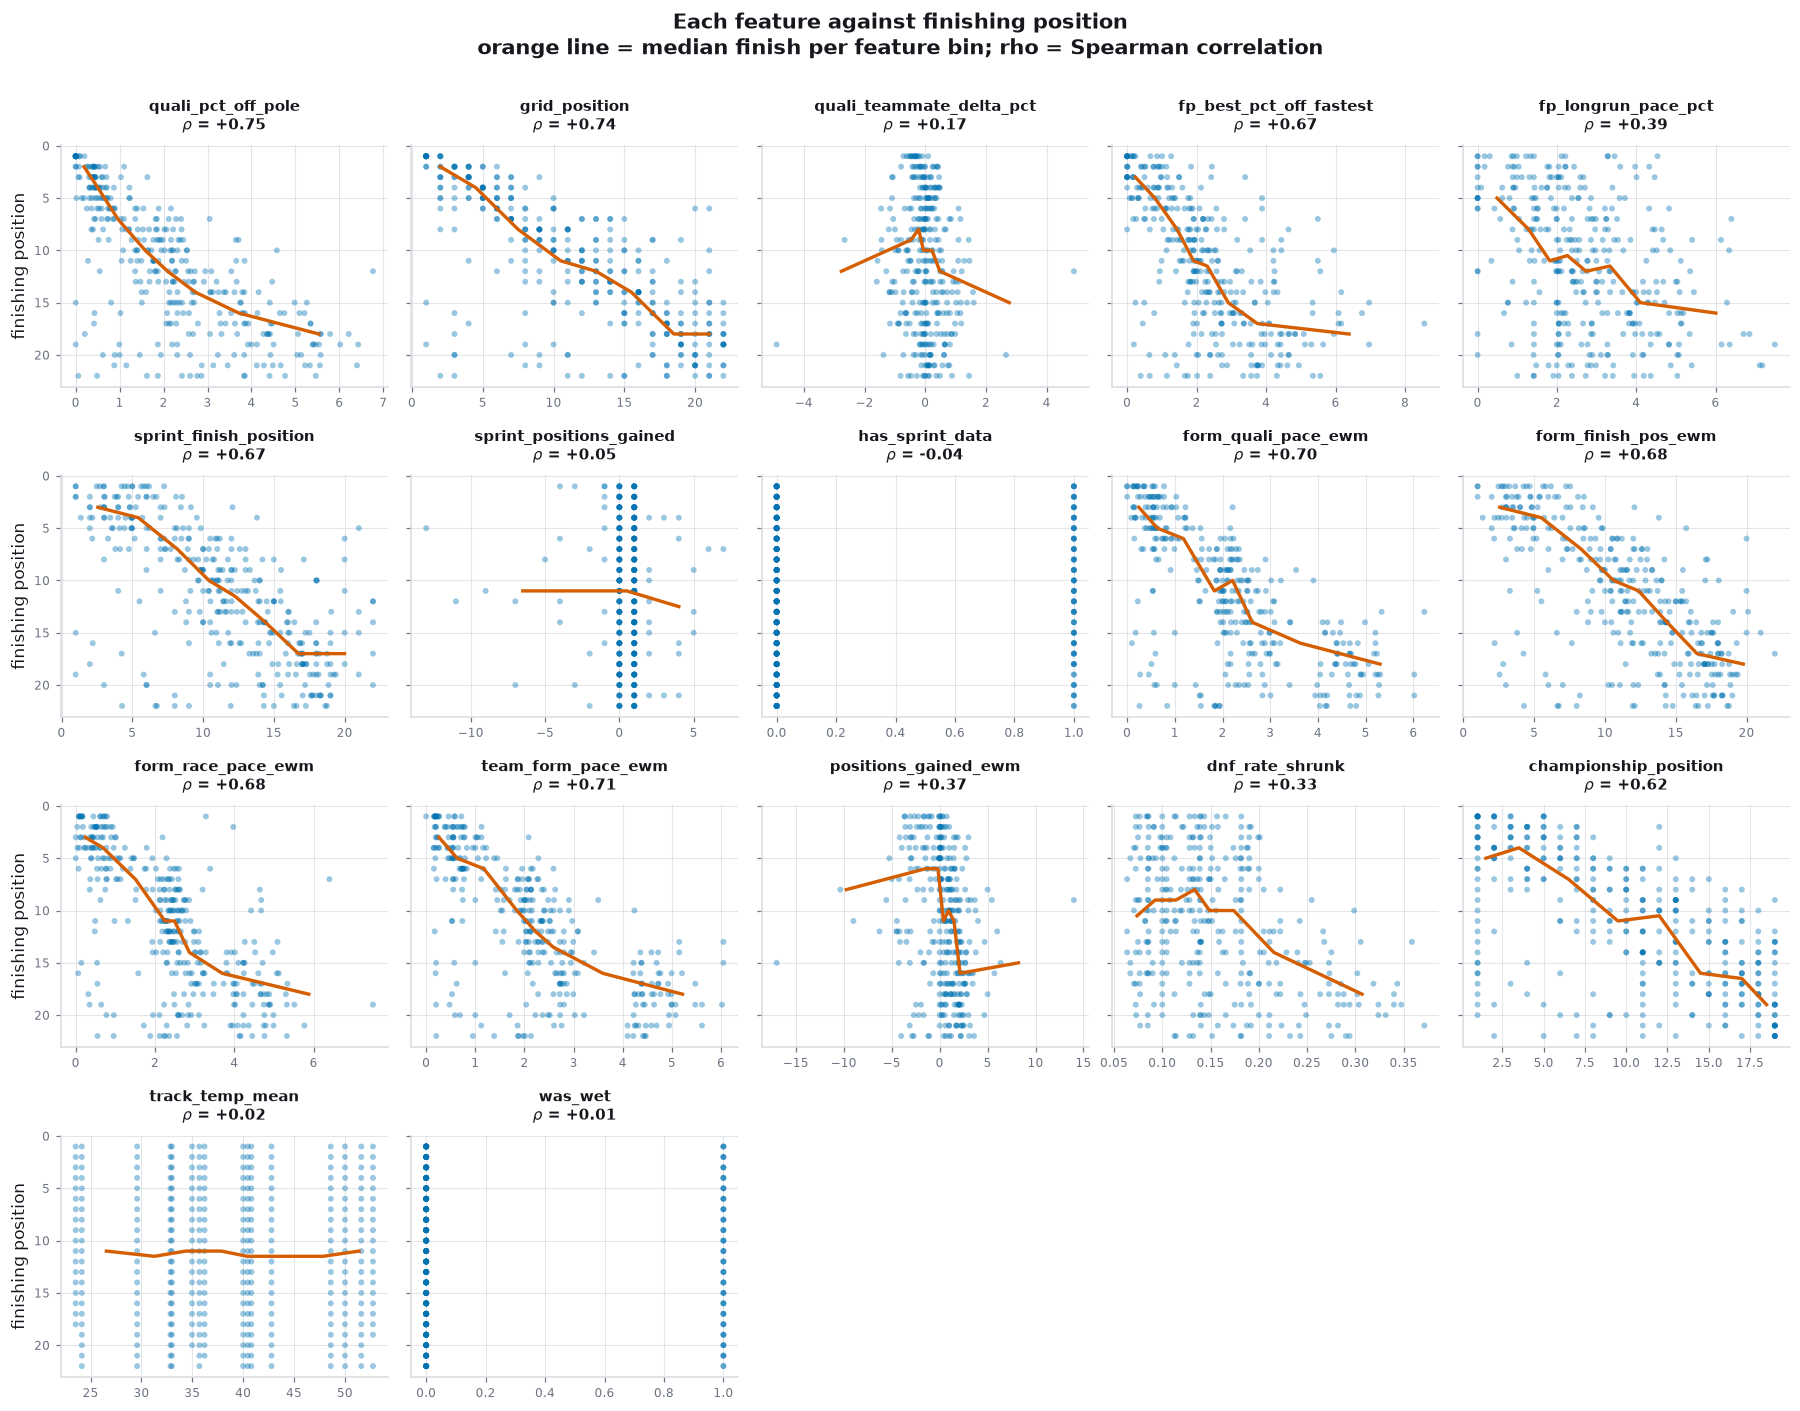

In [15]:
ncols, nrows = 5, int(np.ceil(len(FEATURE_COLUMNS) / 5))
fig, axes = plt.subplots(nrows, ncols, figsize=(16.5, 3.2 * nrows), sharey=True)
for ax, col in zip(axes.ravel(), FEATURE_COLUMNS):
    x = train[col].astype(float)
    ax.scatter(x, train["finish_position"], s=15, alpha=0.4, color=viz.ACCENT,
               edgecolor="none")
    if x.nunique() > 6:  # binned median trend where the feature is continuous
        bins = pd.qcut(x, min(8, x.nunique()), duplicates="drop")
        trend = train.groupby(bins, observed=True)["finish_position"].median()
        centres = [iv.mid for iv in trend.index]
        ax.plot(centres, trend.to_numpy(), color=viz.WARN, linewidth=2.2, zorder=3)
    rho, _ = spearmanr(x, train["finish_position"])
    ax.set_title(f"{col}\n$\\rho$ = {rho:+.2f}", fontsize=10)
    ax.tick_params(labelsize=8)
for ax in axes.ravel()[len(FEATURE_COLUMNS):]:
    ax.set_visible(False)
for ax in axes[:, 0]:
    ax.set_ylabel("finishing position")
axes[0, 0].invert_yaxis()
fig.suptitle("Each feature against finishing position\n"
             "orange line = median finish per feature bin; rho = Spearman correlation",
             fontsize=14, fontweight="bold", y=1.0)
fig.tight_layout()
plt.show()

**What it shows.** Every feature against the target on a common y-axis, with a
binned median trend so the shape of each relationship is visible rather than just
its correlation. It matters because it separates the features with a clean
monotonic relationship — the pace and form group — from those that are flat
(weather, `has_sprint_data`) and those that are monotonic but noisy
(`dnf_rate_shrunk`). Flat panels here are candidates for removal.

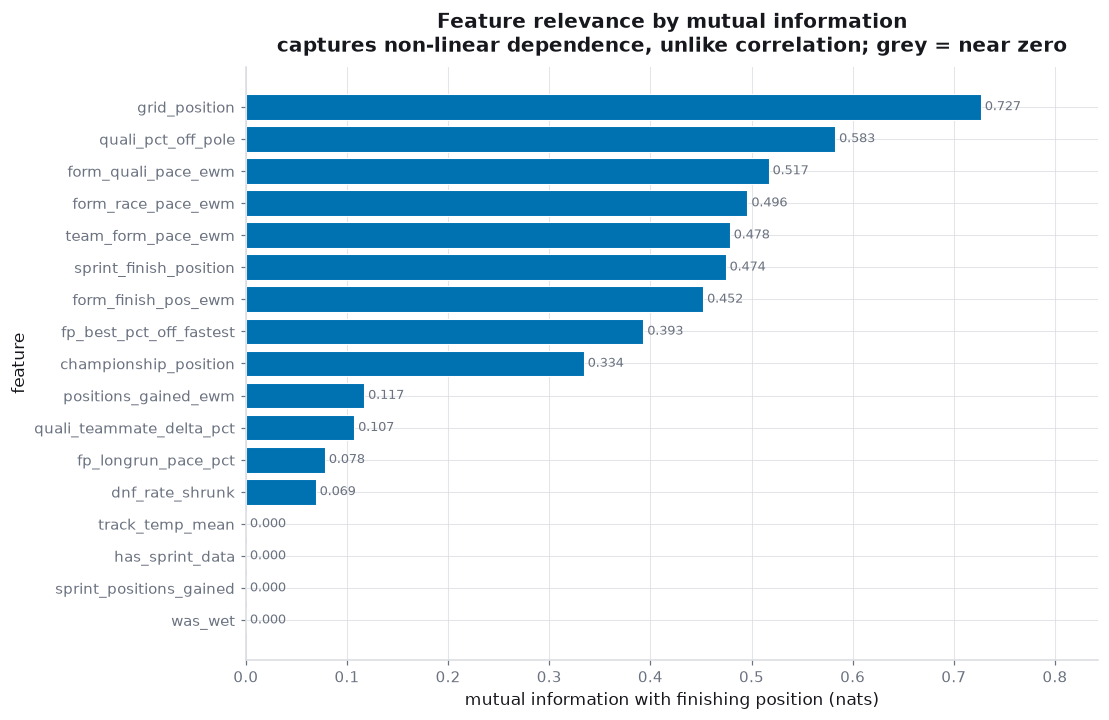

grid_position               0.7266
quali_pct_off_pole          0.5825
form_quali_pace_ewm         0.5168
form_race_pace_ewm          0.4958
team_form_pace_ewm          0.4783
sprint_finish_position      0.4743
form_finish_pos_ewm         0.4520
fp_best_pct_off_fastest     0.3929
championship_position       0.3340
positions_gained_ewm        0.1169
quali_teammate_delta_pct    0.1070
fp_longrun_pace_pct         0.0780
dnf_rate_shrunk             0.0690
sprint_positions_gained     0.0000
track_temp_mean             0.0000
has_sprint_data             0.0000
was_wet                     0.0000


In [16]:
from sklearn.feature_selection import mutual_info_regression

X = train[FEATURE_COLUMNS].astype(float)
y = train["finish_position"].astype(float)
discrete = np.array([train[c].dropna().isin([0, 1, True, False]).all() for c in FEATURE_COLUMNS])
mi = mutual_info_regression(X, y, discrete_features=discrete, random_state=0)
mi_s = pd.Series(mi, index=FEATURE_COLUMNS).sort_values()

fig, ax = plt.subplots(figsize=(10, 7))
colors = [viz.ACCENT if v > 0.05 else viz.MUTED for v in mi_s]
ax.barh(mi_s.index, mi_s.to_numpy(), color=colors, edgecolor="white", linewidth=0.7)
for i, v in enumerate(mi_s):
    ax.text(v + 0.004, i, f"{v:.3f}", va="center", fontsize=8.5, color=viz.MUTED)
ax.set_xlabel("mutual information with finishing position (nats)")
ax.set_ylabel("feature")
ax.set_title("Feature relevance by mutual information\n"
             "captures non-linear dependence, unlike correlation; grey = near zero")
ax.set_xlim(0, mi_s.max() * 1.16)
plt.show()

print(mi_s.sort_values(ascending=False).round(4).to_string())

**What it shows.** Mutual information between each feature and finishing position,
which unlike Pearson correlation picks up non-linear and non-monotonic
dependence. It matters as a cross-check on the correlation ranking: features that
rank high on MI but low on correlation carry structure a linear model would miss,
and features near zero on both are dead weight that should be dropped before
fitting rather than after.

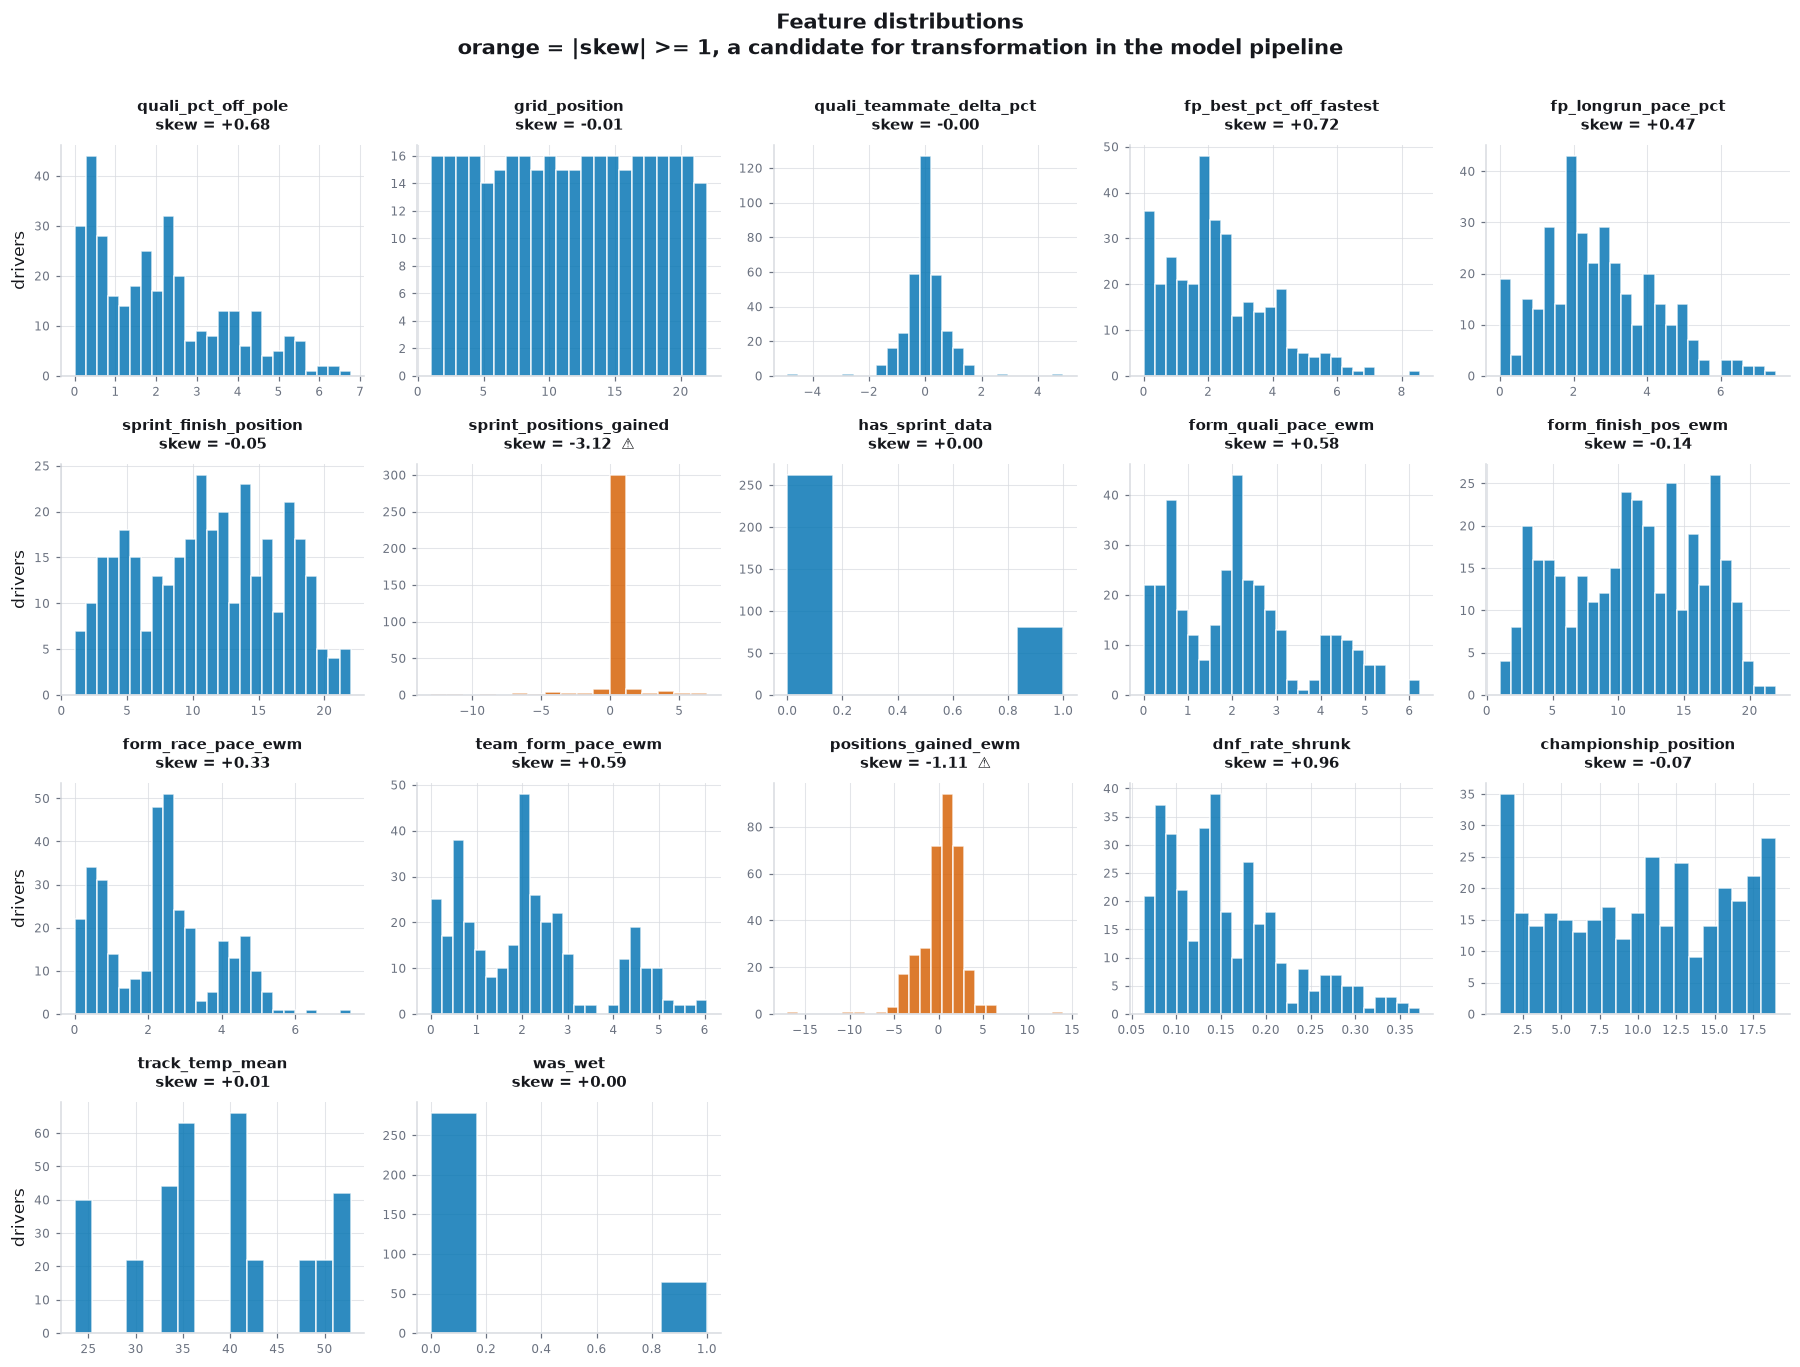

heavily skewed (|skew| >= 1):
  sprint_positions_gained      -3.12
  positions_gained_ewm         -1.11


In [17]:
from scipy.stats import skew

fig, axes = plt.subplots(nrows, ncols, figsize=(16.5, 3.1 * nrows))
flagged = []
for idx, (ax, col) in enumerate(zip(axes.ravel(), FEATURE_COLUMNS)):
    x = train[col].astype(float).dropna()
    sk = float(skew(x)) if x.nunique() > 2 else 0.0
    heavy = abs(sk) >= 1.0
    if heavy:
        flagged.append((col, sk))
    ax.hist(x, bins=min(25, max(6, x.nunique())),
            color=viz.WARN if heavy else viz.ACCENT, alpha=0.82, edgecolor="white")
    ax.set_title(f"{col}\nskew = {sk:+.2f}" + ("  ⚠" if heavy else ""), fontsize=10)
    ax.tick_params(labelsize=8)
    if idx % ncols == 0:
        ax.set_ylabel("drivers")
for ax in axes.ravel()[len(FEATURE_COLUMNS):]:
    ax.set_visible(False)
fig.suptitle("Feature distributions\norange = |skew| >= 1, a candidate for "
             "transformation in the model pipeline", fontsize=14, fontweight="bold", y=1.0)
fig.tight_layout()
plt.show()

print("heavily skewed (|skew| >= 1):")
for col, sk in sorted(flagged, key=lambda t: -abs(t[1])):
    print(f"  {col:<28} {sk:+.2f}")

**What it shows.** The marginal distribution of every feature, with heavy skew
flagged.

The result is not the one to expect. The percentage-gap features are bounded
below at zero and *are* right-skewed, but only mildly — `quali_pct_off_pole`
+0.68, `fp_best_pct_off_fastest` +0.72, the rest between +0.47 and +0.59 — all
comfortably under the |1| threshold and not worth transforming. **The only two
heavily skewed features are the positions-gained pair, and they lean the other
way**: `sprint_positions_gained` at −3.12 and `positions_gained_ewm` at −1.11 are
strongly *left*-skewed, because a driver can lose far more places in one incident
than they can realistically gain. Those two are the transformation candidates for
any linear model, and their long left tail is a reminder that they are partly
measuring accidents.

This is diagnosis only: **no transformation is applied here**, since scaling and
encoding belong in the pipeline where they can be fitted inside cross-validation
folds rather than across them.

---
## 6. Zandvoort 2026

The weekend we are about to predict. FP1, Sprint Qualifying, the Sprint and
Qualifying have all run; the race has not.

sessions on record: ['FP1', 'SQ', 'S', 'Q']
laps per session: {'FP1': 693, 'Q': 377, 'S': 506, 'SQ': 254}


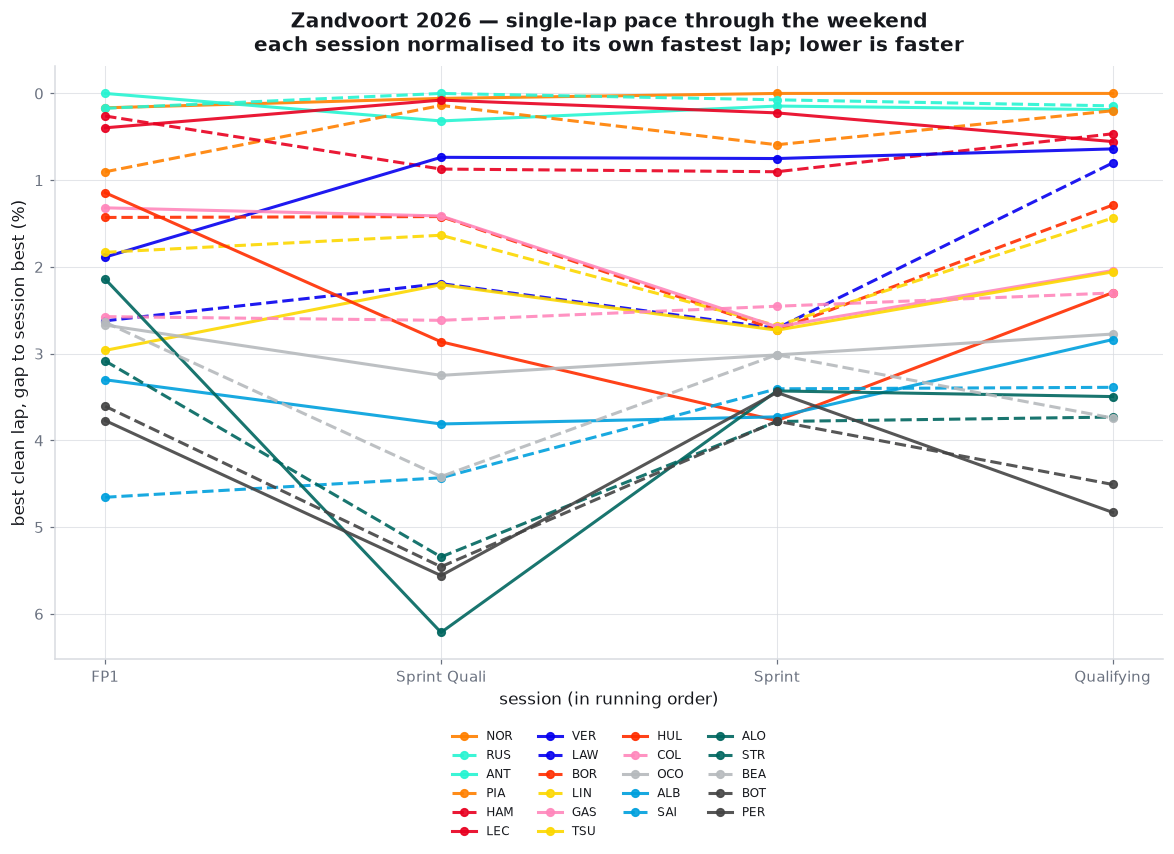

In [18]:
RND = 12
z_laps = laps[laps["round"] == RND].copy()
z_res = results[results["round"] == RND]
print("sessions on record:", sorted(z_laps["session_type"].unique(),
                                   key="FP1 SQ S Q".split().index))
print("laps per session:", z_laps.groupby("session_type").size().to_dict())

# Clean single-lap pace per driver per session, as % off that session's best.
clean = z_laps[(z_laps["IsAccurate"].fillna(False).astype(bool))
               & (~z_laps["Deleted"].fillna(False).astype(bool))
               & (z_laps["TrackStatus"].astype("string") == "1")
               & z_laps["PitInTime_s"].isna() & z_laps["PitOutTime_s"].isna()
               & z_laps["LapTime_s"].notna() & z_laps["DriverId"].notna()]
best = clean.groupby(["session_type", "Driver"])["LapTime_s"].min().rename("best_s").reset_index()
best["pct_off"] = best.groupby("session_type")["best_s"].transform(
    lambda s: (s - s.min()) / s.min() * 100)

SESS = ["FP1", "SQ", "S", "Q"]
pivot = best.pivot(index="Driver", columns="session_type", values="pct_off").reindex(columns=SESS)
order_q = pivot["Q"].sort_values().index

fig, ax = plt.subplots(figsize=(13, 7))
for drv in order_q:
    style = viz.driver_style(drv)
    row = pivot.loc[drv]
    ax.plot(range(len(SESS)), row.to_numpy(), marker="o", markersize=5,
            label=drv, alpha=0.9, **style)
ax.set_xticks(range(len(SESS)))
ax.set_xticklabels(["FP1", "Sprint Quali", "Sprint", "Qualifying"])
ax.set_xlabel("session (in running order)")
ax.set_ylabel("best clean lap, gap to session best (%)")
ax.set_title("Zandvoort 2026 — single-lap pace through the weekend\n"
             "each session normalised to its own fastest lap; lower is faster")
ax.invert_yaxis()
ax.legend(ncol=4, loc="lower center", fontsize=8, bbox_to_anchor=(0.5, -0.32))
plt.show()

**What it shows.** Every driver's best clean lap in each of the weekend's four
sessions, normalised within each session so fuel and tyre differences between
sessions do not dominate. It matters because it shows whose pace is *stable*
across the weekend and whose is not: a driver whose line is flat is a safer
prediction than one who has been jumping around, and the Qualifying column is the
most direct read on Sunday's starting order.

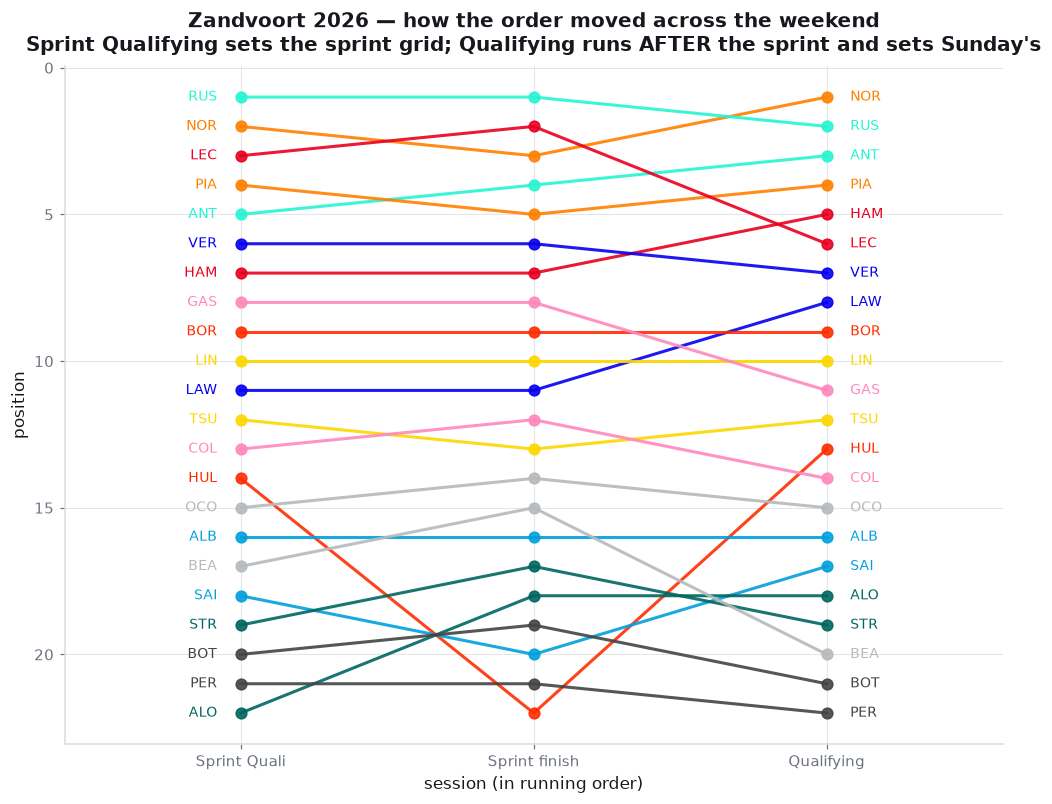

biggest gaps between sprint finish and qualifying position:
              Sprint Quali  Sprint finish  Qualifying  delta
Abbreviation                                                
HUL                   14.0           22.0        13.0    9.0
BEA                   17.0           15.0        20.0   -5.0
LEC                    3.0            2.0         6.0   -4.0
LAW                   11.0           11.0         8.0    3.0
SAI                   18.0           20.0        17.0    3.0
GAS                    8.0            8.0        11.0   -3.0
NOR                    2.0            3.0         1.0    2.0
BOT                   20.0           19.0        21.0   -2.0


In [19]:
# Where the sprint order differed from qualifying. Note the running order:
# Sprint Quali -> Sprint -> Qualifying, so Q is the LATER read.
sq_pos = (z_res[z_res["session_type"] == "SQ"].set_index("Abbreviation")["Position"]
          .rename("Sprint Quali"))
s_pos = (z_res[z_res["session_type"] == "S"].set_index("Abbreviation")["Position"]
         .rename("Sprint finish"))
q_pos = (z_res[z_res["session_type"] == "Q"].set_index("Abbreviation")["Position"]
         .rename("Qualifying"))
teams = z_res[z_res["session_type"] == "Q"].set_index("Abbreviation")["TeamName"]
slope = pd.concat([sq_pos, s_pos, q_pos, teams], axis=1).dropna(subset=["Qualifying"])
slope = slope.sort_values("Qualifying")
slope["delta"] = slope["Sprint finish"] - slope["Qualifying"]

cols = ["Sprint Quali", "Sprint finish", "Qualifying"]
fig, ax = plt.subplots(figsize=(11, 8))
for abbr, row in slope.iterrows():
    color = viz.team_color(row["TeamName"])
    ax.plot(range(3), [row[c] for c in cols], marker="o", markersize=7,
            color=color, alpha=0.9, linewidth=2.0)
    ax.text(-0.08, row[cols[0]], abbr, ha="right", va="center", fontsize=9, color=color)
    ax.text(2.08, row[cols[2]], abbr, ha="left", va="center", fontsize=9, color=color)
ax.set_xticks(range(3)); ax.set_xticklabels(cols)
ax.set_xlim(-0.6, 2.6)
ax.set_ylabel("position")
ax.set_xlabel("session (in running order)")
ax.set_title("Zandvoort 2026 — how the order moved across the weekend\n"
             "Sprint Qualifying sets the sprint grid; Qualifying runs AFTER the sprint "
             "and sets Sunday's")
ax.invert_yaxis()
plt.show()

movers = slope.reindex(slope["delta"].abs().sort_values(ascending=False).index)
print("biggest gaps between sprint finish and qualifying position:")
print(movers[["Sprint Quali", "Sprint finish", "Qualifying", "delta"]].head(8).to_string())

**What it shows.** Each driver's position through Sprint Qualifying, the Sprint
and then Qualifying, in running order. It matters because it isolates who
converted and who did not: a driver who ran well in the sprint but qualified
poorly starts Sunday behind their true pace, and — at a circuit where overtaking
is this hard — is likely to stay there. The `delta` column ranks exactly those
mismatches.

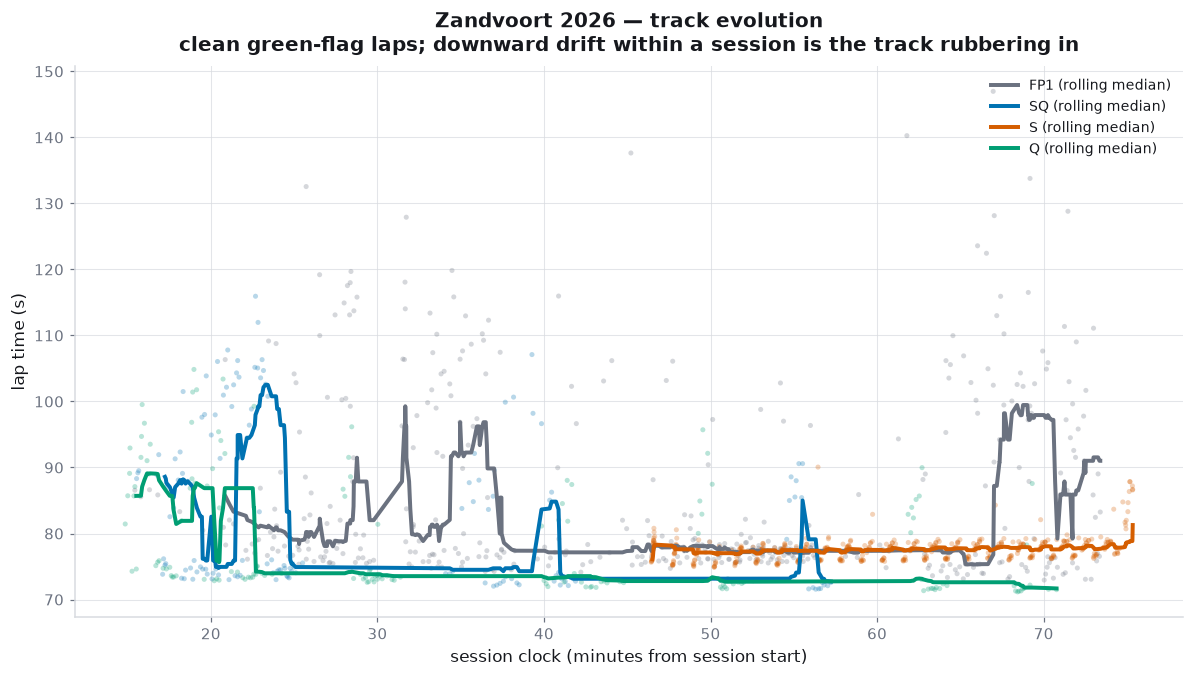

              fastest (s)  median (s)  clean laps
session_type                                     
FP1                72.949      78.140         431
SQ                 71.567      75.545         139
S                  74.881      77.553         479
Q                  71.163      73.682         157


In [20]:
# Track evolution: clean lap times against the session clock.
ev = clean.copy()
ev["clock_min"] = ev["LapStartTime_s"] / 60.0
palette = dict(zip(SESS, ["#6b7280", "#0072b2", "#d55e00", "#009e73"]))

fig, ax = plt.subplots(figsize=(13, 6.5))
for sess in SESS:
    sub = ev[ev["session_type"] == sess].sort_values("clock_min")
    if sub.empty:
        continue
    ax.scatter(sub["clock_min"], sub["LapTime_s"], s=11, alpha=0.28,
               color=palette[sess], edgecolor="none")
    trend = sub.set_index("clock_min")["LapTime_s"].rolling(25, min_periods=8).median()
    ax.plot(trend.index, trend.to_numpy(), color=palette[sess], linewidth=2.6,
            label=f"{sess} (rolling median)")
ax.set_xlabel("session clock (minutes from session start)")
ax.set_ylabel("lap time (s)")
ax.set_title("Zandvoort 2026 — track evolution\n"
             "clean green-flag laps; downward drift within a session is the track "
             "rubbering in")
ax.legend(loc="upper right")
plt.show()

eras = (ev.groupby("session_type")["LapTime_s"].agg(["min", "median", "size"])
        .reindex(SESS).round(3))
eras.columns = ["fastest (s)", "median (s)", "clean laps"]
print(eras.to_string())

**What it shows.** Clean lap times against the session clock, one colour per
session, with a rolling median showing the trend. It matters because the downward
drift inside each session is track evolution — the circuit gets faster as rubber
goes down — which is why practice pace set early in a session understates a car.
Between sessions the comparison is confounded by fuel load and tyre compound, so
read the *slopes*, not the offsets.

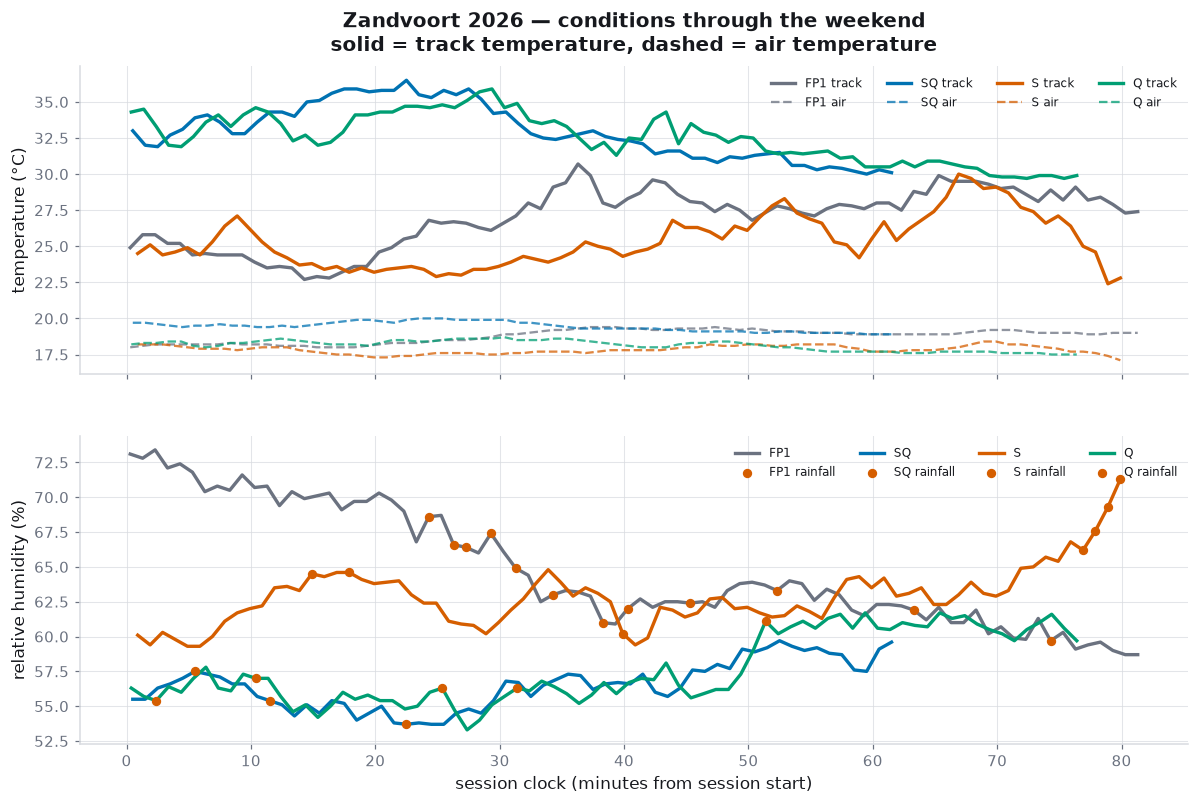

              track_min  track_max  air_mean  humidity_mean  any_rain
session_type                                                         
FP1                22.7       30.7      18.8           64.9      True
SQ                 30.0       36.5      19.4           56.5      True
S                  22.4       30.0      17.8           62.8      True
Q                  29.7       35.9      18.1           57.6      True


In [21]:
z_weather = weather[weather["round"] == RND].copy()
z_weather["clock_min"] = z_weather["Time_s"] / 60.0

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(13, 8), sharex=True)
for sess in SESS:
    sub = z_weather[z_weather["session_type"] == sess].sort_values("clock_min")
    if sub.empty:
        continue
    ax1.plot(sub["clock_min"], sub["TrackTemp"], color=palette[sess], linewidth=2.2,
             label=f"{sess} track")
    ax1.plot(sub["clock_min"], sub["AirTemp"], color=palette[sess], linewidth=1.5,
             linestyle="--", alpha=0.75, label=f"{sess} air")
    ax2.plot(sub["clock_min"], sub["Humidity"], color=palette[sess], linewidth=2.2,
             label=sess)
    wet = sub[sub["Rainfall"].fillna(False).astype(bool)]
    if not wet.empty:
        ax2.scatter(wet["clock_min"], wet["Humidity"], s=26, color=viz.WARN, zorder=4,
                    label=f"{sess} rainfall")
ax1.set_ylabel("temperature (°C)")
ax1.set_title("Zandvoort 2026 — conditions through the weekend\n"
              "solid = track temperature, dashed = air temperature")
ax1.legend(ncol=4, fontsize=8, loc="upper right")
ax2.set_ylabel("relative humidity (%)")
ax2.set_xlabel("session clock (minutes from session start)")
ax2.legend(ncol=4, fontsize=8, loc="upper right")
plt.show()

summary = (z_weather.groupby("session_type")
           .agg(track_min=("TrackTemp", "min"), track_max=("TrackTemp", "max"),
                air_mean=("AirTemp", "mean"), humidity_mean=("Humidity", "mean"),
                any_rain=("Rainfall", lambda s: bool(s.fillna(False).astype(bool).any())))
           .reindex(SESS).round(1))
print(summary.to_string())

**What it shows.** Track and air temperature, humidity and any recorded rainfall
across the weekend's four sessions. It matters because track temperature drives
tyre degradation and therefore strategy, and because the `was_wet` feature is
built from exactly these readings.

> **On the Sunday forecast: there isn't one, and it should not be invented.**
> This dataset contains only *observed* conditions from sessions that have
> already run — FastF1 exposes measurements, not forecasts. Nothing here
> predicts race-day weather. The table above is the honest basis for a prior on
> Sunday (the conditions this circuit has actually produced across the weekend),
> and if a real forecast is wanted it has to come from an external meteorological
> source before the race is locked. Note also that `track_temp_mean` and
> `was_wet` for the round 12 race row are computed from the *earlier* sessions
> of the weekend for exactly this reason — the race's own weather does not exist
> yet.

---
## 7. Findings

Conclusions carried into the modelling notebook. Every number below is read off
the outputs above.

1. **The baseline is grid position, and it is hard to beat.** Starting position
   alone reproduces most of the finishing order (Spearman ρ = 0.745 across 2026
   races and sprints), and the naive "finish where you started" rule already
   achieves a mean absolute error of **2.89 positions**. Baseline **B1** — the
   empirical grid-bucket lookup in section 3 — is the number any model must
   beat, and a model that beats it by less than its own uncertainty is not an
   improvement. Note B1's top rows are thin: P(win) = 0.75 from pole rests on 16
   sessions, so its own error bars are wide.

2. **The usable sample is 343 driver-sessions, and no earlier season can extend
   it.** The 2026 chassis, aerodynamic and power-unit regulations replaced the
   previous formula outright, so pre-2026 pace describes cars that no longer
   exist. This is a small-data problem by construction. Prefer few parameters,
   strong regularisation and heavy shrinkage over flexibility, and read every
   validation score with the sample size in mind.

3. **The feature set is severely collinear — 33 of 136 pairs sit at |r| ≥ 0.70.**
   `grid_position` and `quali_pct_off_pole` correlate at 0.904 because the grid
   *is* the qualifying order up to penalties, and `form_quali_pace_ewm` with
   `team_form_pace_ewm` reaches 0.986. Use ridge or elastic net rather than
   lasso, or keep one representative per cluster. Mutual information ranks
   `grid_position` highest (0.727 vs 0.583), so it is the one to keep — even
   though Spearman marginally prefers `quali_pct_off_pole` (0.762 vs 0.745).

4. **Reliability is distinguishable at the extremes and nowhere else.** The seven
   teams from Alpine (3.1%) to Williams (16.1%) have almost entirely overlapping
   Wilson intervals on ~30 starts each. But Aston Martin (37.5%) and Cadillac
   (31.2%) sit clear of them with non-overlapping intervals — that difference is
   real. This is precisely the case shrinkage handles: the Beta-Binomial
   posterior already in the table compresses the spread from 0–43.8% (sd 12.7)
   to 6.4–34.4% (sd 7.5), letting the extremes move while holding the
   indistinguishable middle together. Do not reintroduce raw DNF rates.

5. **Zandvoort suppresses position change more than any other 2026 circuit, so
   weight the grid more heavily there.** It ranks lowest on both IQR (1.00) and
   mean absolute positions gained (1.09). Critically, this survives the obvious
   confound: mean movement correlates with DNF rate across circuits at r = 0.63,
   but restricting to finishers still leaves **Zandvoort at 0.76 positions
   against Monaco's 3.87**. For the Dutch Grand Prix the prior should be that the
   race finishes close to how it starts.

6. **Four features carry no measurable information and should be dropped before
   fitting.** `was_wet`, `has_sprint_data`, `track_temp_mean` and
   `sprint_positions_gained` all score **exactly 0.000 mutual information** with
   finishing position. This is not a variance problem — `was_wet` splits 65/278
   and `has_sprint_data` 81/262 — they simply do not predict the target. On 343
   rows, dropping them buys back degrees of freedom that cannot be spared.

7. **Treat `sprint_finish_position` with suspicion: its signal is mostly
   borrowed.** It is imputed from `form_finish_pos_ewm` on 76% of rows, which is
   exactly why the two correlate at r = 0.978. Any importance it shows in a
   fitted model will largely be `form_finish_pos_ewm` wearing a different label.
   Either restrict it to the rows where `has_sprint_data` is true, or drop it.

8. **The transformation candidates are the positions-gained features, not the
   pace features.** Contrary to the usual expectation for bounded-at-zero gap
   measures, the percentage features are only mildly right-skewed (+0.47 to
   +0.72) and need no transform. The heavily skewed features are
   `sprint_positions_gained` (−3.12) and `positions_gained_ewm` (−1.11), both
   strongly *left*-skewed because a driver loses more places in one incident than
   they can gain in a clean race. Transform those for linear models; tree models
   are indifferent. Any transform belongs in the pipeline, fitted inside CV
   folds.

9. **Round 1 and round 7 carry less information than the rest.** Every rolling
   feature at round 1 is imputed because no history exists yet, and round 7's
   `fp_longrun_pace_pct` is 54% imputed because FastF1's accuracy check rejects
   most of that weekend's practice laps. Keep both rounds, but do not judge a
   validation fold on round 1, and treat round 7 practice pace as weak evidence.

10. **Driver-to-team mapping is not stable within the season.** There are 23
    drivers across 24 team-driver pairings: Lawson moved from Racing Bulls to Red
    Bull Racing for round 12, the weekend being predicted. Any feature or join
    keyed on a season-level driver-to-team map will mis-assign his rows.
    `src.features` resolves `team_id` per round for this reason.

11. **Sunday's grid is not yet known, and the round 12 rows say so.** The
    `grid_position` values for round 12 are *qualifying order*, not the official
    starting grid; penalties are not reflected and the build emits a loud warning
    to that effect. The published grid must be checked and those rows corrected
    before any prediction is locked.

12. **Race-day weather is unknown and must not be inferred from the weekend.**
    The dataset holds observations, never forecasts, so `track_temp_mean` and
    `was_wet` on the round 12 race row are computed from the weekend's *earlier*
    sessions by design. Rainfall was in fact flagged in all four Zandvoort
    sessions while track temperature ranged 22.4–36.5 °C, so conditions were
    changeable. Since the weather features carry no measured signal (finding 6),
    this affects the qualitative read rather than the model — but a genuinely wet
    race would invalidate the dry-pace assumption underlying most of these
    features, and that call needs an external forecast.